# Angular Distribution of $e^- e^+ \rightarrow \mu^-\mu^+$

In [ ]:
# this is a comment
# import necessaries
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.optimize import curve_fit
import pandas as pd
from IPython.display import display
from tqdm import tqdm # for progress bar

# Section 1:

Creating the class for rejection sampling.

The class contains two forms of the rejection sampling process: one vectorised and one not. The reason behind this is to do with the requirements of investigating the sample distributions across mamy trials. When the sampling method is not vectorised we benefit from a different seed being used each time and maintain a higher degree of randomness in generating the event. However, this is compuationally expensive. 

The vectorisation allows many events to be generated per iteration but does reduce the statistical randomness slightly as muliple events share a generating seed. However, given the large sample sizes being processed by the vectorised variant, this is assumed to have negligable effect on the interpretation of results under the assumption of psedo-randomness as the source of the Monte Carlo's randomness.

In [2]:
class sample_gen:
    """
    A class used to perform rejection sampling according to a given cross section differential equation

    This class contains two functions: 
        1) standard rejection sampling: processes random events one-by-one
        2) vectorised rejection sampling: processes random events in batches

    Arguments
    ----------
    target_func: function
      the differential equation describing the cross section which stands as the target distribution to sample
      according to

    Attributes
    ----------
    self.distribution
        the target distribution
    ==========
    """

    def __init__(self, target_func):
        self.distribution = target_func


    def rej_sampling(self, a1, a2, N, accept, num):
        """
        A function to draw random values from a described range, find their corresponding value from the target
        distribution and compare to a randomly drawn comparison value, C, for determination of accepting the
        value or not.

        Parameters
        ----------
        a1: float
            the first defined coefficient in the differential equation
        a2: float
            the second defined coefficient in the differential equation
        N: int
            the number of accepted values to generate
        accept: float
            half of the symmetric distance from the origin of the range of values to sample from
        num: int
            the resolution of the initial linear space to find the maximum value of the distribution

        Returns
        ----------
        accepted_vals: array
            list of unsorted accepted values across the described range
        p_max: float
            the maxmimum value of the distribution across the range
        total_vals: int
            the total number of sampled values during rejection sampling

        ==========
         """
        # 1. convert inputs to correct type 
        a1, a2, accept =float(a1), float(a2), float(accept)
        # 2. find p_max
        xs = np.linspace(-accept, accept, num)
        p_max = 0
        for val in xs: #cycle through x values
          p = self.distribution(val, a1, a2)
          if p > p_max:
            p_max = p

        # 3. storing accepted event values
        accepted_vals = []
        total_vals = 0
        # 4. generating random events according to target distribution 
        while len(accepted_vals) < N:
            # 5. draw a uniformly random value from within the acceptance region
            samp_val = np.random.uniform(-accept, accept, size=1)[0]
            # 6. uniformly random comparison
            c_val = np.random.uniform(0, p_max, 1)
            # 7. rejection sampling condition
            if self.distribution(samp_val, a1, a2) > c_val:
                accepted_vals.append(samp_val)
            total_vals += 1
        
        return np.array(accepted_vals), p_max, total_vals


    def vectorised_rej_sampling(self, a1, a2, N, accept, num): 
        """
        The vectorised variant of .rej_sampling()

        Parameters
        ----------
        a1: float
            the first defined coefficient in the differential equation
        a2: float
            the second defined coefficient in the differential equation
        N: int
            the number of accepted values to generate
        accept: float
            half of the symmetric distance from the origin of the range of values to sample from
        num: int
            the resolution of the initial linear space to find the maximum value of the distribution
        
        Returns
        ----------
        accepted_vals: array
            list of unsorted accepted values across the described range
        p_max: float
            the maxmimum value of the distribution across the range
        total_vals: int
            the total number of sampled values during rejection sampling
        n_accepted: int
            the total number of accepted values process by the vectorised batches

        """
        # 1. convert inputs to correct type 
        a1, a2, accept, num, N = float(a1), float(a2), float(accept), int(num), int(N)
        # 2. searching for pmax
        xs = np.linspace(-accept, accept, num)
        p_max = np.max(self.distribution(xs, a1, a2))

        # 3. for storing event values
        accepted_vals = []
        total_vals = 0
        # 4. defining the batch of events to generate
        batch_size = int(2*N)
        
        while len(accepted_vals) < N:
            # 5. create uniformly random cos(theta) values 
            samp_vals = np.random.uniform(-accept, accept, size=batch_size)
            # 6. uniformly random comparison values 
            c_vals = np.random.uniform(0, p_max, size=batch_size)
            # 7. only consider the indices of those points meeting the rejection sampling criteria by masking
            mask = self.distribution(samp_vals, a1, a2) > c_vals
            accepted_vals.extend(samp_vals[mask])
            total_vals += batch_size

        # 8. the actual amount of accepted values generated. Batch processing means n_accept ≥ N
        n_accepted = len(accepted_vals)
        # 9. crop accepted values to length N. Mimics generating N indivdual events since all events are independent 
        accepted_vals = np.array(accepted_vals[:int(N)]) 
        
        return accepted_vals, p_max, total_vals, n_accepted

Defining the function for the differential cross section

In [3]:
def target_func(x, a1, a2):
    """
    A function describing the target differential equation describing the cross-section

    Parameters
    ----------
    x: numpy.ndarray, shape=(1, D)
      Called first inline with SciPy curve fitting software requirements.
      A 1D array of positions to evaluate the function at
    a1, a2: float
        coefficients

    Returns
    ----------
    result: numpy.ndarray, shape=(1, D)
      the function evaluated at all points in x
    ==========
    """
    # 1. cross section function where cos(theta) = x
    result = 1 + a1*x + a2*x**2

    return result

Performing the rejection sampling to produce a histogram of the target function

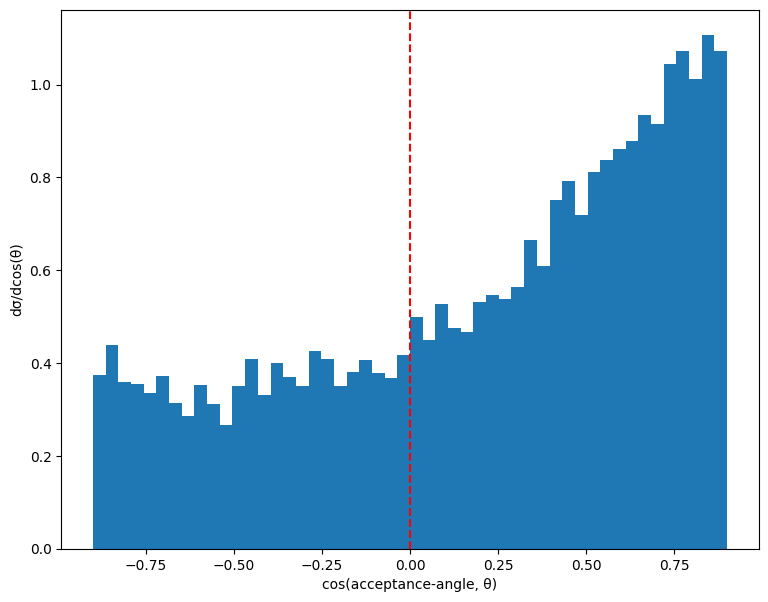

fraction of points positive: 0.6724, fraction of negative: 0.3276
Integral estimation using average probability: 2.2735


In [4]:
# 1. constants needed
N = 10000
a1 = 1.
a2 = 1.
# the angular acceptance limit: |cos(θ)| ≤ accept
accept = 0.9

# 2. initialising the class
sample_generator = sample_gen(target_func)
# 3. assigning values to the vectorised rejection sampling 
accepted_vals, p_max, total_vals, n_accepted = sample_generator.vectorised_rej_sampling(a1, a2, N, accept, num=10000)
# 4. finding the number of points above/below zero
pos = len([n for n in accepted_vals if n>0])
neg = len(accepted_vals) - pos

# 5. calculating the integral estimate using n_accepted 
p_avg = (n_accepted/total_vals) * p_max
area_est = p_avg * 2*accept

# 6. plotting the histogram
fig = plt.figure(figsize=(9, 7))
plt.hist(np.sort(accepted_vals), bins=50, density=True)
plt.axvline(0, ls='--', c='r')
plt.xlabel(f'cos(acceptance-angle, θ)')
plt.ylabel('dσ/dcos(θ)')
plt.show()

# 7. printing the pos:neg fraction and the integral estimate 
print(f'fraction of points positive: {pos/len(accepted_vals)}, fraction of negative: {neg/len(accepted_vals)}')
print(f'Integral estimation using average probability: {area_est:.4f}')

Now I'll find the integral of the derivative function using SciPy to act as a means of testing the validity of the rejection sampling method

Area under curve: 2.2860
Above fraction: 0.6772 , Below fraction: 0.3228


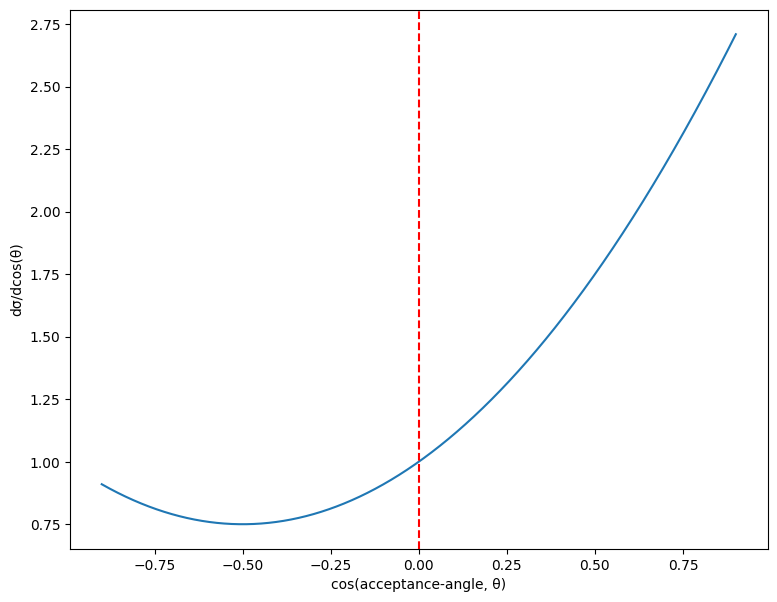

In [5]:
# 1. defining constants 
a1 = 1.
a2 = 1.
# 2. cropped linspace for detector acceptance consideration
x = np.linspace(-0.9, 0.9, 10000)
# 3. overall integral
result = sp.integrate.quad(target_func, -0.9, 0.9, args=(a1, a2))[0]
# 4. x-positive integral
result_plus = sp.integrate.quad(target_func, 0, 0.9, args=(a1, a2))[0]
# 5. x-negative integral
result_minus = sp.integrate.quad(target_func, -0.9, 0, args=(a1, a2))[0]

# 6. print results
print(f'Area under curve: {result:.4f}')
print(f'Above fraction: {result_plus/result :.4f} , Below fraction: {result_minus/result:.4f}')
# 7. plotting 
fig = plt.figure(figsize=(9, 7))
plt.plot(x, target_func(x, a1, a2))
plt.axvline(0, ls='--', c='r')
plt.xlabel(f'cos(acceptance-angle, θ)')
plt.ylabel('dσ/dcos(θ)')
plt.show()

Analytically:
$$ \frac{d\sigma}{d\text{cos}(\theta)} \propto 1 + a_1\text{cos}(\theta) + a_2\text{cos}^2(\theta)$$
Integrate with respect to cos($\theta$)
$$ \sigma = \left[  \text{cos}(\theta) + \frac{a_1}{2}\text{cos}^2(\theta) + \frac{a_2}{3}\text{cos}^3(\theta) \right]^{0.9}_{-0.9} $$
$$ \implies \sigma = 2(0.9) + \frac{2a_2}{3}(0.9)^3$$
Where the proportionality has been dropped, since the coefficient would just be a scaling constant.

Using $a_2 = 1$:
$$ \sigma = 2(0.9) + 2/3 (0.9)^3 = 2.286 $$

### Section 1 Summary:
- using rejection sampling, its possible to recover the integral of the differential
- using the integral and number of samples taken, we can recover the number of events below/above cos$(\theta) = 0$
#### Note on using `n_accepted` over `accepted_vals`:
`n_accepted` is just the total number of values of $cos(\theta)$ accepted by the rejection sampling process using batches. `accepted_vals` *IS* the array storing the actual values and truncated to have shape (1, N) instead of shape(1, n_accept). By truncating the array down to size `N` we do not lose any statistical inference as events are randomly sampled and not sorted. Therefore, before truncation, there's no correlation between sucessive values in the array i.e it's not like `accepted_vals = [-0.99, -0.98, -0.97, ..., 0.96, 0.97...] but rather [-0.16, 0.43, -0.89, 0.03, ...]. 

We then use `accepted_vals` and `N` to define the array of accepted values and how many of them we're interested in modelling.

---------------------------------------------

# Section 2:

In this question, the aim is to infer the values of a1 and a2, and to see how the accuracy with which I can find them depends on the number of events `N`

## Task 1: Describe the distribution using rejection sampling

First, let's visualise the binned-fit distribution of the differential equation describing the cross-section.

To do this, choose a random pairing of what will be the true values of (a1, a2) and perform rejection sampling with `N` successful values sampled within the defined range, `(-accept, accept)` according to the `target_func`.

We can then create a binned fit for these accepted values within the range, which reproduces the shape of the target function with some noise, which is inherent from Monte Carlo sampling.

In [6]:
def distribution_descrip(
    target_func, 
    sample_gen_class,
    N,
    a1,
    a2,
    accept,
    chi_sq,
    unvectorise = False, 
    res = None
):
    """
    This function is for describing the distribution of the target function using rejection sampling. It does this by taking the accepted
        event values of cos(theta) and creating a binned fit. From this we can plot a histogram to visualise the cross section function 
        and extract necessary information to estimate true (a1, a2)

    Parameters
    ----------
    target_func: function
        the target function to perform rejection sampling on
    sample_gen_class: class
        the class responsible for generating samples according to rejection sampling
    N: int
        the number of accepted values from rejection sampling
    a1: float
        the first coefficient in target_func
    a2: float
        the second coefficient in target_func
    accept: float
        cosine of the angular acceptance
    chi_sq: bool
        when True, we just want the parameters without the plot
    unvectorise: bool 
        Boolean option if one requires a non-vectorised approach
    res: float, default=None
        the resolution to be set if completing Question 3

    Returns
    ----------
    xhist: array-like
        centres of the histogram bins
    yhist: array-like
        heights of the histogram bars
    bin_widths: float
        the width of each bin
    p_max: float
        maximum value of the target function within the desired range (with some uncertainty)
    area_est: float
        the estimated integral of the target function
    total_vals: int
        total number of values tried in the rejection sampling
    accepted_vals: array
        array of the values of the accepted values in rejection sampling

    histogram of the distribution if chi_sq == False

    ==========
    """
    # 0. convert to correct types 
    N, a1, a2, accept = int(N), float(a1), float(a2), float(accept)
    
    # 1. class instance 
    sample_generator = sample_gen_class(target_func)
    # 2. choose method 
    if unvectorise: 
        accepted_vals, p_max, total_vals = sample_generator.rej_sampling(a1, a2, N, accept, num=10000)
        # 2a. calculating the integral estimate using n_accepted
        p_avg = (len(accepted_vals)/total_vals) * p_max
    else:
        # 2b. Question 3's method requires a larger 'N' since we crop out certain values afterwards. Keep same N for normal
        if res is not None:
            N_prime = int(N / 0.8) + 1000  # Generate extra for acceptance loss
        else:
            N_prime = N
            
        accepted_vals, p_max, total_vals, n_accepted = sample_generator.vectorised_rej_sampling(a1, a2, N_prime, accept, num=10000) # using VECTORISED version
        # 2c. calculating the integral estimate using n_accepted
        p_avg = (n_accepted/total_vals) * p_max

        # 2d. this is where the detector acceptance and angular resolution come into play 
        if res is not None:
            # 2e. extract theta 
            theta = np.arccos(accepted_vals)
            
            # 2f. add Gaussian noise according to angular resolution to smear angles
            resolution = 1e-3 * res # convert mrad -> rad 
            theta_smeared = theta + np.random.normal(0, resolution, size=len(theta))
            
            # 2g. clip within range of [0, pi] 
            theta_smeared = np.clip(theta_smeared, 0, np.pi)
            
            # 2h. plug back into cosine
            measured_cosine = np.cos(theta_smeared)
            
            # 2i. mask out values above the acceptance
            mask = abs(measured_cosine) <= accept 
            measured_cosine = measured_cosine[mask]
            
            # 2j. Take exactly N events (if we have enough)
            if len(measured_cosine) < N:
                print(f"Only {len(measured_cosine)} events after cuts, wanted {N}!")
            accepted_vals = measured_cosine[:N]

    # 3. finding the number of points above/below zero
    pos = np.sum(accepted_vals > 0)
    neg = len(accepted_vals) - pos

    # 4. calculate the estimated integral area
    area_est = (p_avg * 2*accept)

    # 5. number of histogram bins
    bin_num = 70
    # 6. the bin positions
    bins = np.linspace(min(accepted_vals), max(accepted_vals), bin_num + 1)
    # 7. find the bar heights
    yhist, bins = np.histogram(accepted_vals, bins=bins, density=True)
    # 8. centres of the bins
    xhist =(bins[1:] + bins[:-1])/2
    # 9. the width of each bin (single value)
    bin_widths = np.diff(bins)[0]

    # 10. plotting the function if we're not interested in chi_sq for goodness of fit
    if chi_sq == False:

        # 11. print some useful information
        print(20*'=')
        print(f'fraction of points positive: {pos/len(accepted_vals)}, fraction of negative: {neg/len(accepted_vals)}')
        print(f'Integral estimation using average probability: {area_est}')
        print(20*'=')
        
        # 12. Plot the histogram
        fig = plt.figure(figsize=(9, 7))
        plt.stairs(yhist, bins, label='Binned Data', fill=True)
        plt.plot(xhist, yhist, c='r', label='Rough function shape')
        plt.axvline(0, ls='--', c='orange')
        plt.xlabel(f'cos(acceptance-angle, θ)')
        plt.ylabel('Normalised probaility density')
        plt.legend()
        plt.show()
    # 13. return what's useful
    return [xhist, yhist, bin_widths, p_max, area_est, total_vals, accepted_vals]

fraction of points positive: 0.7103, fraction of negative: 0.2897
Integral estimation using average probability: 2.22751805372512


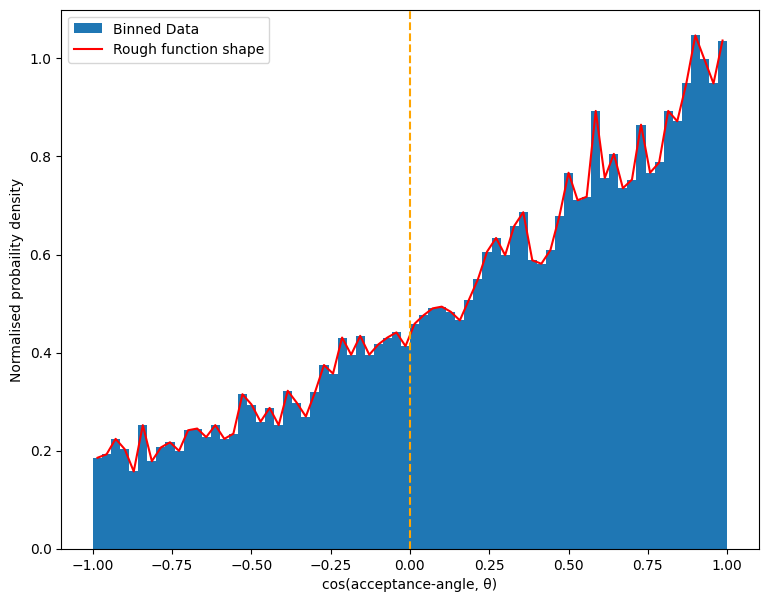

random value of a1 = 0.9503732504620419
 random value of a2 = 0.3461554919732588


In [7]:
# 1. defining contstants/parameters
N = 1e4
# 2. Random a1 a2 values. These will be kept constant throughout the remainder of the project 
a1 = np.random.uniform(-1, 1, 1)[0]
a2 = np.random.uniform(-1, 1, 1)[0]
# 3. the angular acceptance limit: |cos(θ)| ≤ accept
accept = 1.

# 4. assign values
xhist, yhist, bin_widths, p_max, area_est, total_vals, accepted_vals = distribution_descrip(
    target_func, sample_gen, N, a1, a2, accept, chi_sq=False)

# 5. printing the parameters
print(20*'=')
print(f'random value of a1 = {a1}\n',
      f'random value of a2 = {a2}')
print(20*'=')

#### It should be noted that there are values of a1 and a2 which seem to result in the tail end of the distribution falling short of containing points within [-1, 1] range. This is the same for both the vectorised and non-vectorised methods

Note about the interpretation of the histogram bar heights:

`yscaled`: When `density=True` in the histogram, it makes it advantageous to plot distributions over. However, to get the raw y-value back we must rescale the bar height. This means that the bin height:
$$\text{Bar Height} = \frac{\text{Bin raw count}}{\text{Total number of counts}\times\text{Bin width}} $$
Therefore, to get the functional height of the bar, we now multiply this probability by the integral area.

## Task 2: Estimating $a_1$ from The Forwards-Backwards Asymmetry

Question: "Study how the accuracy with which you can determine the values of the parameters a1 and a2 depends
on the number of events for the forward-backward asymmetry method (for which you should assume
that a2 has been measured) and a binned fit. Assume a detector with perfect acceptance. Do your
error estimates provide a good description of the actual parameter variance?"

The cross-section differential equation is:
$$ \frac{d\sigma}{d\text{cos}(\theta)} \propto 1 + a_1\text{cos}(\theta) + a_2\text{cos}^2(\theta) $$
The Forward-Backward Asymmetry is defined as:
$$A_{FB} = \frac{N_{+} - N_{-}}{N_{+} + N_{-}} $$
The cross-section equation can be integrated between [-1, 1], [0, 1] and [-1, 0] to realise the following respective results:
$$\sigma = N_{-} + N_{+} = 2 + \frac{2a_2}{3} $$
$$N_{+} = 1 + \frac{a_1}{2} + \frac{a_2}{3} $$
$$N_{-} = 1 - \frac{a_1}{2} + \frac{a_2}{3} $$
Combining these together and resolving for $a_1$:
$$a_1 = 2\left( 1 + \frac{a_2}{3}\right)A_{FB} = 2\left( 1 + \frac{a_2}{3}\right)\left( \frac{N_{+} - N_{-}}{N_{+} + N_{-}}  \right) $$

**HOWEVER** when we consider the restricted detector acceptance, we must change the integral limits since it is no longer the ideal case. Therefore, new limits are [-0.9, 0.9] yielding:

$$a_1 = 2\left( \frac{1}{0.9} + \frac{(0.9)a_2}{3}\right)A_{FB}$$

This allows us to estimate the value of $a_1$ if we know the number of events contained either side of $\text{cos}(\theta) = 0$. After getting one estimate, we can repeat this process again for `M` times to get an uncertainty. This is due to the estimated value being a result of the $A_{FB}$ process, which is statistically random. Therefore, given a sufficiently large M, the accumulated $a_1$ values should produce a Normal distribution, with a standard deviation suitable to define the uncertainty.

If one does this process for fixed *true* values of $a_1, a_2$, and then repeats by changing ONLY the value of $a_1$, recording the average estimated value `a1_FB` along with its uncertainty, a plot can be produced of $A_{FB}$ on the vertical axis and *true* values $a_1$ on the horizontal.

Plotting the estimated values, with uncertainty error bars, with then allow one to only know the Forward-Backward Asymmetry and infer the *true* value of $a_1$ that would produce such asymmetry (with an associated error)

In [8]:
# ==========
# now we can estimate the value of a1, given that we've been provided with a2
# ==========

# 1. finding the number of points above/below zero
pos = len([n for n in accepted_vals if n>0])
neg = len(accepted_vals) - pos
# 2. definition of forward-backward asymmetry
a1_FB = 2*(1 + a2/3) * (pos - neg)/(N)
# 3. print real and predicted
print('True a1: {:.3f}\nPredicted a1: {:.3f}'.format(a1, a1_FB))

True a1: 0.950
Predicted a1: 0.938


In [9]:
# ==========
# defining the function to provide estimates of a1 and A_FB, whilst keeping a2 constant, across M samples
# ==========


def estimates(
    M, # M: number of estimates/samples to produce for a single a1_FB
    distribution_descrip, 
    target_func, 
    sample_gen,
    N, 
    a1, 
    a2,
    accept,
    res=None
): 
    """
    This function is for estimating a1 and A_FB for M samples produced for a fixed true (a1, a2)

    Parameters
    ----------
    M: int
        number of samples
    distribution_descrip: callable
        the function for calculating the accepted values from rejection sampling
    target_func: callable
        target function for rejection sampling
    sample_gen: class
        class for rejection sampling
    N: int
        number of events recorded
    a1, a2: float
        true values of a1 and a2 
    accept: float, range(-1, 1)
        the one-sided acceptance
    res: float, default=None
        angular resolution 

    Returns
    ----------
    a1_estimates, AFB_estimates: array, shape=(1, M)
        estimated values for a1 and AFB. Due to Monte Carlo sampling we get Normally distributed values
    """
    # 0. convert to needed form 
    M, N, a1, a2, accept = int(M), int(N), float(a1), float(a2), float(accept)
    # 1. empty list to store estimates
    a1_estimates = []
    AFB_estimates = []
    # 2. for each sample: 
    for m in range(M):
        # 3. if we're doing Question 3 we need smeared data:
        if res is not None:
            _, _, _, _, _, _, accepted_vals = distribution_descrip(
            target_func, sample_gen, N, a1, a2, accept, chi_sq=True, res=res) # dont want to plot so chi_squ=True 

            # 4.finding the number of points above/below zero
            pos = np.sum(accepted_vals > 0)
            neg = len(accepted_vals) - pos
            # 5. forward-backward 
            A_FB = (pos - neg)/(N)
            # 6. a1 estimate from analytical solution 
            a1_FB = 2*(1/0.9 + (0.9)*a2/3) * A_FB
            # 7. add estimates to arrays
            a1_estimates.append(a1_FB)
            AFB_estimates.append(A_FB)
            
        else:
            _, _, _, _, _, _, accepted_vals = distribution_descrip(
                target_func, sample_gen, N, a1, a2, accept, chi_sq=True) # dont want to plot so chi_squ=True 
        
            # 4.finding the number of points above/below zero
            pos = np.sum(accepted_vals > 0)
            neg = len(accepted_vals) - pos
            # 5. forward-backward 
            A_FB = (pos - neg)/(N)
            # 6. a1 estimate from analytical solution 
            a1_FB = 2*(1 + a2/3) * A_FB
            # 7. add estimates to arrays
            a1_estimates.append(a1_FB)
            AFB_estimates.append(A_FB)

    return a1_estimates, AFB_estimates

In [10]:
# 1. Parameters
M = 500
N = 1e4
# 2. asaign values accordingly
a1_estimates, AFB_estimates = estimates(M, distribution_descrip, target_func, sample_gen, N, a1, a2, accept)
# 3. print results 
print(20*'=')
print('True values: a1={:.3f}, a2={:.3f}'.format(a1, a2))
print('Mean estimated a1 value: a1={:.3f}'.format(np.mean(a1_estimates)))
print(20*'=')

True values: a1=0.950, a2=0.346
Mean estimated a1 value: a1=0.950


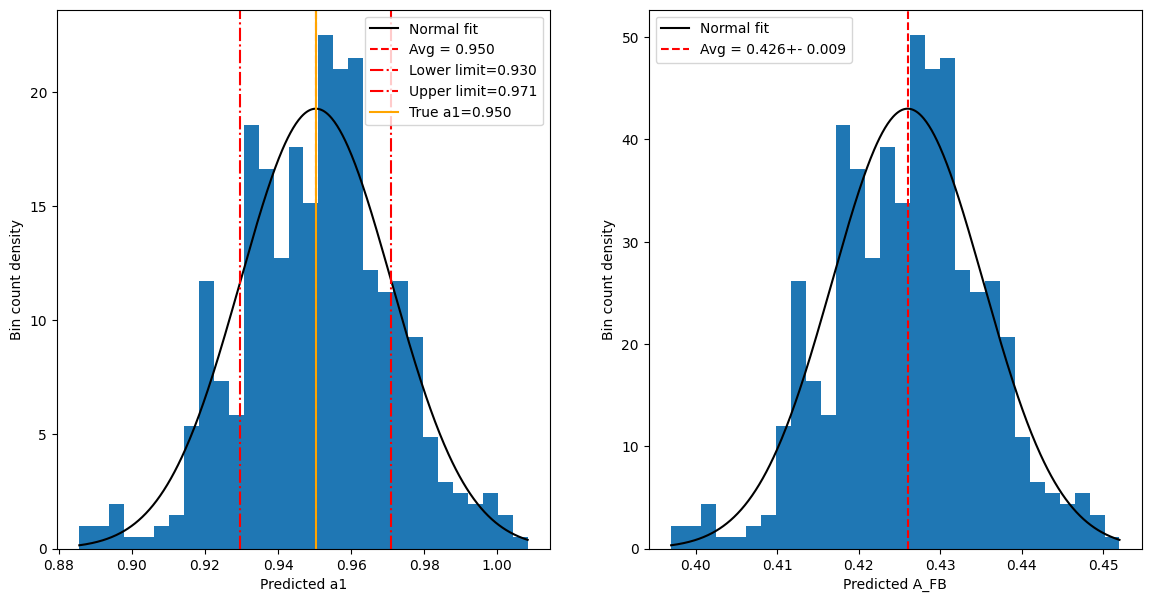

Using the forward-backward asymmetry consideration, assuming we know the true value for a2,
 we have predicted the value of a1 to be (0.950+-0.021).
This provides a range of [0.930, 0.971], meaning the true value of
a1 is! contained within the uncertainty bounds


In [11]:
# ==========
# this cell is for creating a binned fit of the estimates for a1 and A_FB, allowing us to visualise the convergence to a normal distribution 
#     (given a sufficiently large M). This is where we extract an uncertainty on a1's estimate from the std of the normal fit 
# ==========


# 1. describing the distribution of a1_estimates
pred_a1_mean = np.mean(a1_estimates)
pred_a1_std = np.std(a1_estimates)
pred_a1_lower = pred_a1_mean - abs(pred_a1_std)
pred_a1_upper = pred_a1_mean + abs(pred_a1_std)

# 2. describing the distribution of AFB_estimates
A_FB_mean = np.mean(AFB_estimates)
A_FB_std = np.std(AFB_estimates)

# 3. plotting:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14,7))

# 4a. plotting the distribution of predicted a1 values 
ax[0].hist(a1_estimates, bins=30, density=True)
# 5a. plotting Gaussian fit 
val_range = np.linspace(min(a1_estimates), max(a1_estimates), len(a1_estimates)) #range of values
norm = 1/(np.sqrt(2*np.pi)*pred_a1_std) * np.exp(-(val_range - pred_a1_mean)**2 / (2*pred_a1_std**2))
# 6a. figure formatting 
ax[0].plot(val_range, norm, c='black', label='Normal fit')
ax[0].axvline(pred_a1_mean, linestyle='--', c='r', label=f'Avg = {pred_a1_mean:.3f}')
ax[0].axvline(pred_a1_lower, linestyle='-.', c='r', label=f'Lower limit={pred_a1_lower:.3f}')
ax[0].axvline(pred_a1_upper, linestyle='-.', c='r', label=f'Upper limit={pred_a1_upper:.3f}')
ax[0].axvline(a1, c='orange', linestyle='-', label=f'True a1={a1:.3f}')
ax[0].set_xlabel('Predicted a1')
ax[0].set_ylabel('Bin count density')
ax[0].legend()

# 4b. plotting the distribution of A_FB estimates
ax[1].hist(AFB_estimates, bins=30, density=True)
# 5b. plotting Gaussian fit 
val_range2 = np.linspace(min(AFB_estimates), max(AFB_estimates), len(AFB_estimates)) #range of values
norm = 1/(np.sqrt(2*np.pi)*A_FB_std) * np.exp(-(val_range2 - A_FB_mean)**2 / (2*A_FB_std**2))
# 6b. figure formatting 
ax[1].plot(val_range2, norm, c='black', label='Normal fit')
ax[1].axvline(A_FB_mean, linestyle='--', c='r', label=f'Avg = {A_FB_mean:.3f}+- {A_FB_std:.3f}')
ax[1].set_xlabel('Predicted A_FB')
ax[1].set_ylabel('Bin count density')
ax[1].legend()
plt.show()

# 7. printing results and condition on whether a1's estimate is 'close' to the true value (ie witin its error)
print(20*'=')
print(f'Using the forward-backward asymmetry consideration, assuming we know the true value for a2,\n we have predicted the value of a1 to be ({pred_a1_mean:.3f}+-{pred_a1_std:.3f}).')
if pred_a1_lower <= a1 <= pred_a1_upper:
    outcome = 'is'
else:
    outcome = 'is not'
print(f'This provides a range of [{pred_a1_lower:.3f}, {pred_a1_upper:.3f}], meaning the true value of\na1 {outcome}! contained within the uncertainty bounds')
print(20*'=')

Now we have visualised the distribution for one trial of true (a1, a2) values, we repeat the process for a range of true a1 values, keeping a2 fixed, and plot the result.

It should be noted that the following code does take a little while to run, and so vectorisation was added to the rejction sampling process to improve this.

In [13]:
def parameter_est(
    True_A1s, 
    a2,
    values, 
    N, 
    M, 
    accept, 
    res=None
): 
    """
    This function provides [a1_mean, a1_error] and [A_FB_mean, A_FB_error] when varying the true a1 and measuring its 
        influence on A_FB, given a fixed a2

    Parameters
    ----------
    True_A1s: array, shape=(1, values)
        array containing the different true a1's to sample for
    a2: float
        a2 value (fixed)
    values: int
        number of different true a1's to sample for
    N: int
        the length of the accepted value array
    M: int
        the number of samples to generate per true a1
    accept: float
        the detector acceptance
    res: float, default=None
        the resolution for smearing in question 3

    Returns
    ----------
    a1_info, A_FB_info: array, shape=(values, 2)
        for each true a1 it stores [a1_mean, a1_error] and [A_FB_mean, A_FB_error]
    """
    # 1. create arrays to store (a1_estimate, a1_error) abd (A_FB_estimate, A_FB_error)
    a1_info = np.empty(shape=(values, 2))
    A_FB_info = np.empty(shape=(values, 2))
    
    # 2. loop through all true a1's
    for i, a1_true in enumerate(True_A1s):
        # 3. get estimate arrays, considering the resolution if Question 3
        if res is not None:
            a1_estimates, AFB_estimates = estimates(M, distribution_descrip, target_func, sample_gen, N, a1_true, a2, accept, res) 
        else:
            a1_estimates, AFB_estimates = estimates(M, distribution_descrip, target_func, sample_gen, N, a1_true, a2, accept) 
        
        # 4. describing the distribution of a1_estimates
        a1_mean = np.mean(a1_estimates)
        a1_std = np.std(a1_estimates)
    
        # 5. describing the distribution of A_FB values
        A_FB_mean = np.mean(AFB_estimates)
        A_FB_std = np.std(AFB_estimates)
    
        # 6. add to information arrays
        a1_info[i] = a1_mean, a1_std
        A_FB_info[i] = A_FB_mean, A_FB_std

    return a1_info, A_FB_info

In [14]:
# 1. define M samples to estimate a1 with for each true a1 value
M = 500
# 2. number of accepted events for rejection sampling
N = 1e4
# 3. the angular acceptance limit: |cos(θ)| ≤ accept
accept = 1.
# 4. define linspace for TRUE a1 values to take
values = 20
True_A1s = np.linspace(-0.1, 0.1, values)
# 5. extract information from function
a1_info, A_FB_info = parameter_est(True_A1s, a2, values, N, M, accept)

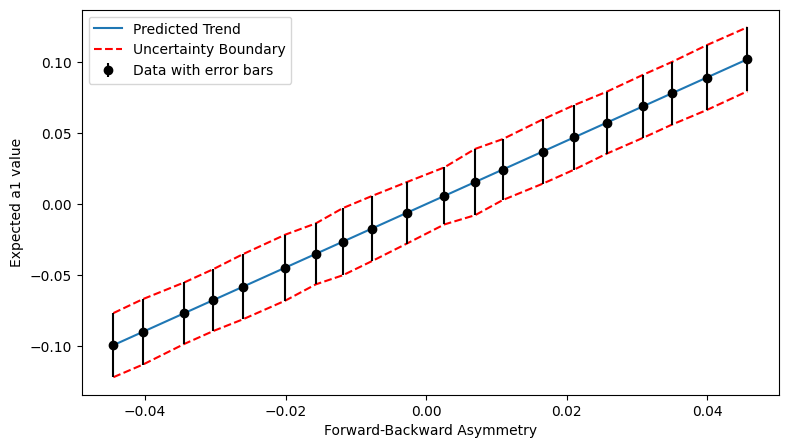

In [15]:
# plotting expected a1 as a function of A_FB
fig = plt.figure(figsize=(9, 5))
# 1. upper and lower uncertainty boundaries
a1_uppers = a1_info[:, 0] + a1_info[:, 1]
a1_lowers = a1_info[:, 0] - a1_info[:, 1]
# 2. plotting the uncertainty boundaries and data trend 
plt.plot(A_FB_info[:, 0], a1_info[:, 0], label="Predicted Trend")
plt.plot(A_FB_info[:, 0], a1_lowers, c='r', linestyle='--', label='Uncertainty Boundary')
plt.plot(A_FB_info[:, 0], a1_uppers, c='r', linestyle='--')
# 3. plotting the actual data with error bars
plt.errorbar(x=A_FB_info[:,0], y=a1_info[:,0], yerr=a1_info[:,1], color='black', ls='none', fmt='o', label='Data with error bars')
plt.xlabel('Forward-Backward Asymmetry')
plt.ylabel('Expected a1 value')
plt.legend()
plt.show()

#### Interpretation:
If the forward-backward asymmetry is a known quantity from observation, one should then be able to find the corresponding `expected a1 value` and it's uncertainty between the two boundaries.

The above figure also shows that the uncertainty on the expected $a_1$ value remains fairly constant, demonstrated by the two guide lines forming the uncertainty boundary being somewhat parallel to the data trend. What will be interesting to test is how the `average uncertainty` varies with `N`, which is the number of events, especially when considering the relative uncertainty (error/mean). This can be done by creating a log-space of `N` values and repeating the above process. 

The reason why checking the *relative error* is more important is due to the size of the error bars being rather significant. In most cases, we want a close estimate of what the true a1 value is and not `a1_est ± abs(a1_est)` for instance.

The following code will take a moment to run due to the larger `N`, hence a progression stat has been added to reassure one that the code is running.

In [16]:
# 1. define the range of N values to take 
N_range = np.logspace(start=1, stop=4, num=10)
# 2. create arrays for storing relative and absolute error averages at each N
avg_rel_error = np.empty(shape=(len(N_range), 1))
avg_abs_error = np.empty(shape=(len(N_range), 1))
# 3. define M samples to estimate a1 with for each true a1 value. Large enough for CLT but computationally manageable
M = 500
# 4. the angular acceptance limit: |cos(θ)| ≤ accept
accept = 1.
# 5. define linspace for TRUE a1 values to take
values = 20
True_A1s = np.linspace(-0.1, 0.1, values)

# 6. loop through N values
for j, N in enumerate(N_range):
    # 7. print iteration and N
    print(j+1,'/',len(N_range), f', N = {N:.0f}')
    
    # 8. extract mean a1 and a1 std. a1_info = (a1_mean, a1_std)
    a1_infoB, _ = parameter_est(True_A1s, a2, values, N, M, accept) # denote B to retain the original a1_info
    
    # 9. For each true a1, calculate relative and absolute uncertainty
    epsilon = 1e-5 # prevents divide by zero
    rel_uncertainties = a1_infoB[:,1] / (np.abs(a1_infoB[:,0])+epsilon)  # std / |mean_estimate|
    abs_uncertainties = np.abs(a1_infoB[:, 1])
    
    # 10. The uncertainty results are arrays (which we used to produce the a1 Vs A_FB plot)...
    # ...so we average across all true a1 values
    avg_rel_error[j] = np.mean(rel_uncertainties)
    avg_abs_error[j] = np.mean(abs_uncertainties)


1 / 10 , N = 10
2 / 10 , N = 22
3 / 10 , N = 46
4 / 10 , N = 100
5 / 10 , N = 215
6 / 10 , N = 464
7 / 10 , N = 1000
8 / 10 , N = 2154
9 / 10 , N = 4642
10 / 10 , N = 10000


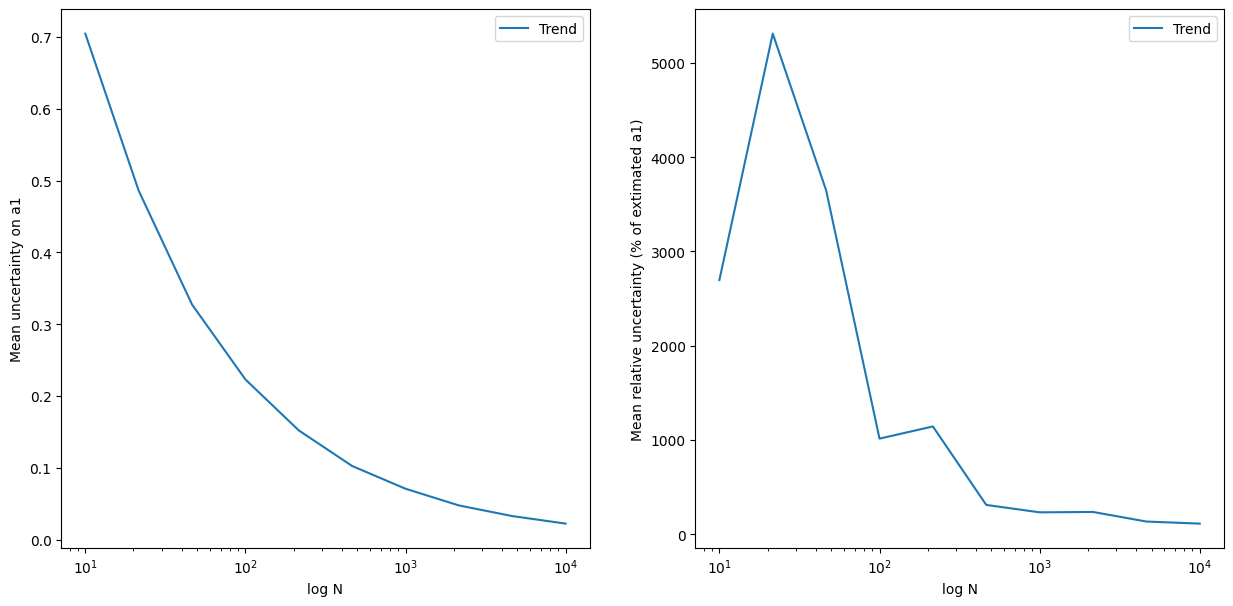

In [17]:
# plotting the results
figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,7))

# 1. plotting absolute uncertainty Vs log(N)
ax[0].plot(N_range, avg_abs_error, label='Trend')
ax[0].set_xlabel('log N')
ax[0].set_ylabel('Mean uncertainty on a1')
ax[0].set_xscale('log')
ax[0].legend()

# 2. plotting relative uncertainty Vs log(N)
ax[1].plot(N_range, avg_rel_error*100, label='Trend')
ax[1].set_xlabel('log N')
ax[1].set_ylabel('Mean relative uncertainty (% of extimated a1)')
ax[1].set_xscale('log')
ax[1].legend()
plt.show()

## Section 3 Detector Effects Simulation

Study the effects of detector acceptance and resolution on the sensitivity. For example the LEP detectors could typically identify muons and measure their charge in the region $|\cos\theta| < 0.9$ with an angular resolution of $\lesssim 3$ mrad.

The way to approach this:
- define the new acceptance $= 0.9$
- define the resolution required in mrad
- keep $N$ the same (see why later)
- call the `distribution_describ()` function with $N$, $\text{accept}$ and $\text{res}$
    - the function will create $N' = \text{int}(N/0.9) + 1000$
    - it passes this new $N'$ along with other information into the rejection sampling function
    - it takes the arguments from the accepted_vals (which are the cosines) and smears the angle according to the angular resolution
    - it then takes the cosine of this new smeared angle
    - finally, it clips the values within the acceptance and crops the array down to size $N$
- what's returned is histogram information now for the clipped and smeared event data

The power with this approach is that we maintain a uniform distribution on the $\cos(\theta)$ generated events, as is the case in the previous case. Had an angle been uniformly sampled then the cosine distribution would not be uniform but rather be:

$$
P(\cos(\theta)) = \csc(\theta) \, \mathbf{U}(0, \pi)
$$

using a change of variables 

$$y = f(\theta) = \cos(\theta)$$

$$\theta \sim \mathbf{U}(0, \pi)$$

which creates more problems than it solves.

fraction of points positive: 0.6908, fraction of negative: 0.3092
Integral estimation using average probability: 1.9557517106723425


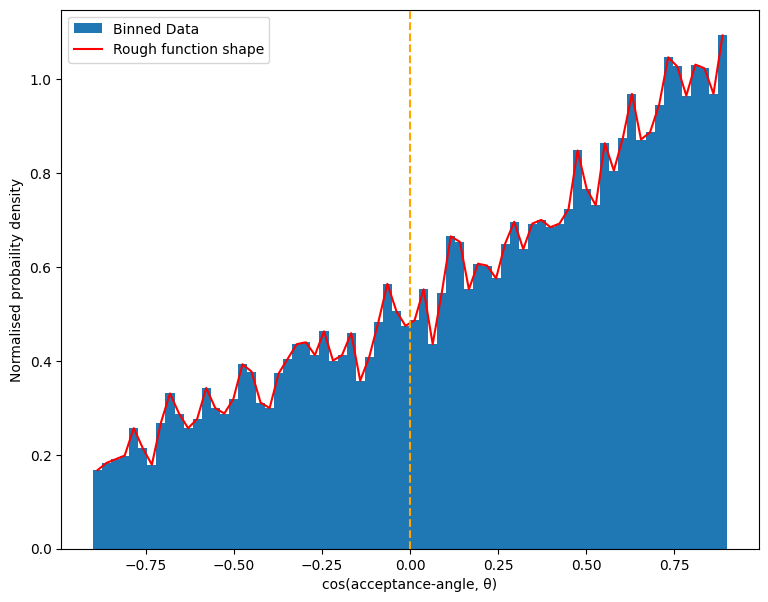

The minimum and maximum values of cosine are:  -0.89 0.89
--------------------


In [18]:
# 1. new acceptance range
accept2 = 0.9
# 2. resolution
res = 3.
# 3. define N 
N = 1e4

# 4. generate a histogram 
xhist2, yhist2, bin_widths2, p_max2, area_est2, total_vals2, accepted_vals2 = distribution_descrip(
    target_func, sample_gen, N, a1, a2, accept2, chi_sq=False, res=res)
# 5. print minimum and maximum accepted cosine values 
print('The minimum and maximum values of cosine are: ', round(min(xhist2), 2), round(max(xhist2), 2))
print(20*'-')

Now we can estimate the value of $a_1$ by iterating across `M` samples and producing a plot of the resulting distribution, the same as we did for the ideal scenario:

In [19]:
# 1. Parameters
M = 500
N = 1e4
accept2 = 0.9
res = 3. 
# 2. assign values accordingly
a1_estimates2, AFB_estimates2 = estimates(M, distribution_descrip, target_func, sample_gen, N, a1, a2, accept2, res=res)
# 3. print results 
print(20*'=')
print('True values: a1={:.3f}, a2={:.3f}'.format(a1, a2))
print('Mean estimated a1 value: a1={:.3f}'.format(np.mean(a1_estimates2)))
print(20*'=')

True values: a1=0.950, a2=0.346
Mean estimated a1 value: a1=0.950


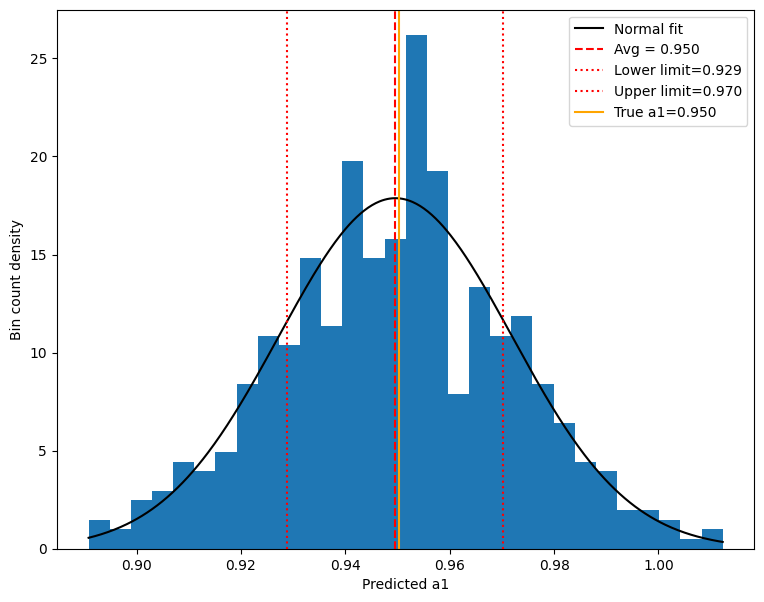

Using the forward-backward asymmetry consideration, assuming we know the true value for a2,
 we have predicted the value of a1 to be (0.950+-0.022).
This provides a range of [0.929, 0.970], meaning the true value of
a1 is! contained within the uncertainty bounds


In [20]:
# ==========
# this cell is for creating a binned fit of the estimates for a1 and A_FB, allowing us to visualise the convergence to a normal distribution 
#     (given a sufficiently large M). This is where we extract an uncertainty on a1's estimate from the std of the normal fit 
# ==========


# 1. describing the distribution of a1_estimates
pred_a1_mean2 = np.mean(a1_estimates2)
pred_a1_std2 = np.std(a1_estimates2)
pred_a1_lower2 = pred_a1_mean2 - abs(pred_a1_std)
pred_a1_upper2 = pred_a1_mean2 + abs(pred_a1_std)

# 2. describing the distribution of AFB_estimates
# A_FB_mean = np.mean(AFB_estimates2)
# A_FB_std = np.std(AFB_estimates2)

# 3. plotting:
fig= plt.figure(figsize=(9,7))

# 4a. plotting the distribution of predicted a1 values 
plt.hist(a1_estimates2, bins=30, density=True)
# 5a. plotting Gaussian fit 
val_range2 = np.linspace(min(a1_estimates2), max(a1_estimates2), len(a1_estimates2)) #range of values
norm2 = 1/(np.sqrt(2*np.pi)*pred_a1_std2) * np.exp(-(val_range2 - pred_a1_mean2)**2 / (2*pred_a1_std2**2))
# 6a. figure formatting 
plt.plot(val_range2, norm2, c='black', label='Normal fit')
plt.axvline(pred_a1_mean2, linestyle='--', c='r', label=f'Avg = {pred_a1_mean2:.3f}')
plt.axvline(pred_a1_lower2, linestyle=':', c='r', label=f'Lower limit={pred_a1_lower2:.3f}')
plt.axvline(pred_a1_upper2, linestyle=':', c='r', label=f'Upper limit={pred_a1_upper2:.3f}')
plt.axvline(a1, c='orange', linestyle='-', label=f'True a1={a1:.3f}')
plt.xlabel('Predicted a1')
plt.ylabel('Bin count density')
plt.legend()
plt.show()

# 7. printing results and condition on whether a1's estimate is 'close' to the true value (ie witin its error)
print(20*'=')
print(f'Using the forward-backward asymmetry consideration, assuming we know the true value for a2,\n we have predicted the value of a1 to be ({pred_a1_mean2:.3f}+-{pred_a1_std2:.3f}).')
if pred_a1_lower2 <= a1 <= pred_a1_upper2:
    outcome = 'is'
else:
    outcome = 'is not'
print(f'This provides a range of [{pred_a1_lower2:.3f}, {pred_a1_upper2:.3f}], meaning the true value of\na1 {outcome}! contained within the uncertainty bounds')
print(20*'=')

In *some* cases, it may be evident to see that the `True a1` lies further away from the `Avg` than in the previous case with perfect detection and angular resolution. However, in both cases we retain a Gaussian fit across many samples (CLT).

Now we'll plot the expected a1 Vs A_FB:

In [21]:
# 1. define M samples to estimate a1 with for each true a1 value
M = 500
# 2. number of accepted events for rejection sampling
N = 1e4
# 3. the angular acceptance limit: |cos(θ)| ≤ accept
accept = 0.9
# 4. resolution
res = 3.
# 5. define linspace for TRUE a1 values to take
values = 20
True_A1s = np.linspace(-0.1, 0.1, values) # same range as previous
# 6. extract information from function
a1_info2, A_FB_info2 = parameter_est(True_A1s, a2, values, N, M, accept, res)

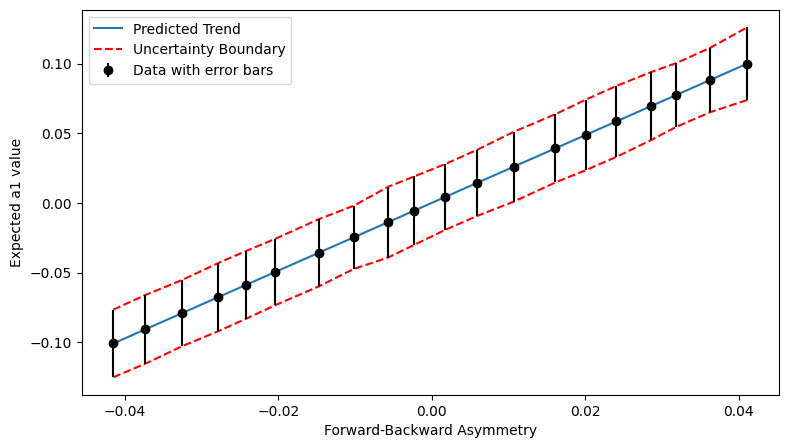

In [22]:
# plotting expected a1 as a function of A_FB
fig = plt.figure(figsize=(9, 5))
# 1. upper and lower uncertainty boundaries
a1_uppers2 = a1_info2[:, 0] + a1_info2[:, 1]
a1_lowers2 = a1_info2[:, 0] - a1_info2[:, 1]
# 2. plotting the uncertainty boundaries and data trend 
plt.plot(A_FB_info2[:, 0], a1_info2[:, 0], label="Predicted Trend")
plt.plot(A_FB_info2[:, 0], a1_lowers2, c='r', linestyle='--', label='Uncertainty Boundary')
plt.plot(A_FB_info2[:, 0], a1_uppers2, c='r', linestyle='--')
# 3. plotting the actual data with error bars
plt.errorbar(x=A_FB_info2[:,0], y=a1_info2[:,0], yerr=a1_info2[:,1], color='black', ls='none', fmt='o', label='Data with error bars')
plt.xlabel('Forward-Backward Asymmetry')
plt.ylabel('Expected a1 value')
plt.legend()
plt.savefig('a1_AFB_trend.png')
plt.show()

Again, it may be evident to see that the width of the error bars have increased, sometimes doubling when compared to the ideal case in Question 2.

Quantitatively, we'll see this by plotting the absolute and relative error with increasing N:

In [23]:
# 1. define the range of N values to take 
N_range = np.logspace(start=1, stop=4, num=10)
# 2. create arrays for storing relative and absolute error averages at each N
avg_rel_error2 = np.empty(shape=(len(N_range), 1))
avg_abs_error2 = np.empty(shape=(len(N_range), 1))
# 3. define M samples to estimate a1 with for each true a1 value. Large enough for CLT but computationally manageable
M = 500
# 4. the angular acceptance limit: |cos(θ)| ≤ accept
accept = 0.9
# 5. resolution
res = 3.
# 6. define linspace for TRUE a1 values to take
values = 20
True_A1s = np.linspace(-0.1, 0.1, values)

# 7. loop through N values
for j, N in enumerate(N_range):
    # 8. print iteration and N
    print(j+1,'/',len(N_range), f', N = {N:.0f}')
    
    # 9. extract mean a1 and a1 std. a1_info = (a1_mean, a1_std)
    a1_info2B, _ = parameter_est(True_A1s, a2, values, N, M, accept, res) # denote B to retain the original a1_info2
    
    # 10. For each true a1, calculate relative and absolute uncertainty
    epsilon = 1e-5 # prevents divide by zero
    rel_uncertainties2 = a1_info2B[:,1] / (np.abs(a1_info2B[:,0])+epsilon)  # std / |mean_estimate|
    abs_uncertainties2 = np.abs(a1_info2B[:, 1])
    
    # 11. The uncertainty results are arrays (which we used to produce the a1 Vs A_FB plot)...
    # ...so we average across all true a1 values
    avg_rel_error2[j] = np.mean(rel_uncertainties2)
    avg_abs_error2[j] = np.mean(abs_uncertainties2)

1 / 10 , N = 10
2 / 10 , N = 22
3 / 10 , N = 46
4 / 10 , N = 100
5 / 10 , N = 215
6 / 10 , N = 464
7 / 10 , N = 1000
8 / 10 , N = 2154
9 / 10 , N = 4642
10 / 10 , N = 10000


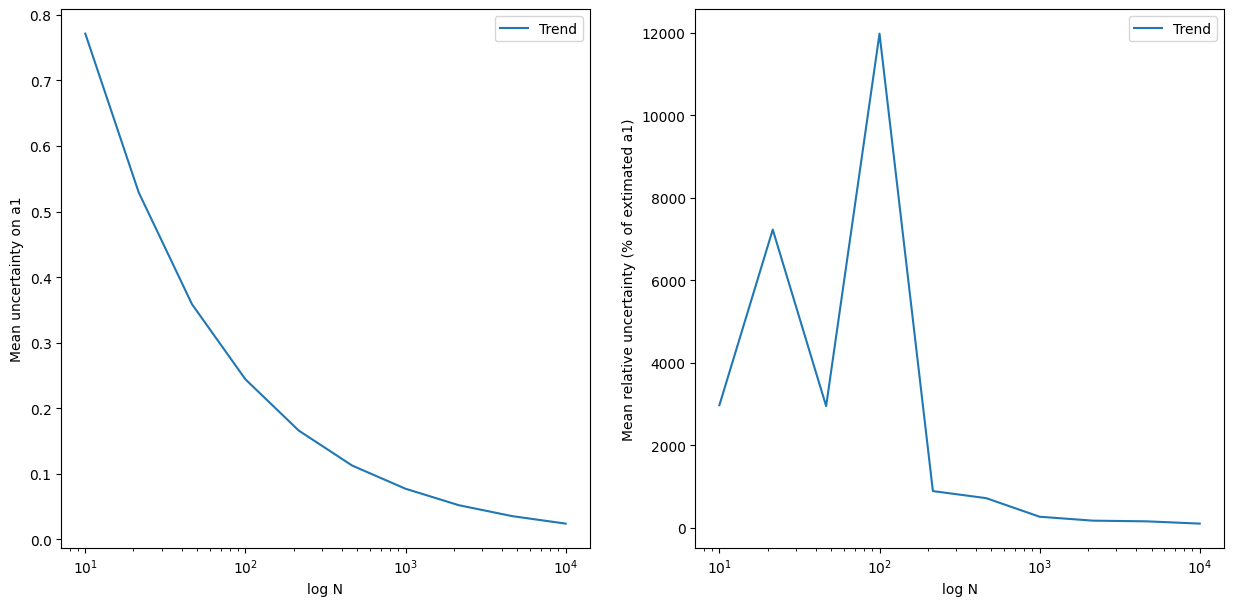

In [24]:
# plotting the results
figure, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,7))

# 1. plotting absolute uncertainty Vs log(N)
ax[0].plot(N_range, avg_abs_error2, label='Trend')
ax[0].set_xlabel('log N')
ax[0].set_ylabel('Mean uncertainty on a1')
ax[0].set_xscale('log')
ax[0].legend()
plt.savefig('a1_AFB_trend.png')

# 2. plotting relative uncertainty Vs log(N)
ax[1].plot(N_range, avg_rel_error2*100, label='Trend')
ax[1].set_xlabel('log N')
ax[1].set_ylabel('Mean relative uncertainty (% of extimated a1)')
ax[1].set_xscale('log')
ax[1].legend()
plt.show()

Whilst the overall shape and tendency might be common between the idealised case and with detector restrictions, the relative uncertainty is larger (visually). Frequently, there appears to be extremely large peaks formed for $N \sim 100$. Whilst it may be tempting to think this is caused by the mean estimate for a1 being zero, we first take the absolute value of the means so we can almost always guarantee `a1_mean > 0`. This is likely the cause of statistical uncertainty yielding extremely large relative errors.

To finish, let's format these results more clearly in a table

In [25]:

# 1. regenerate predicted values for a1 using both methods for N = 1e3 and 1e4 
a1_q3_vals = np.empty(shape=(2, 2))
a1_q2_vals = np.empty(shape=(2, 2))
# 2. Parameters
M = 500
ns = [1e3, 1e4]
res = 3. 
accept = 1.
accept2 = 0.9

# 3. loop through N values for question 2
for i, n in enumerate(ns):
    # 4. assign values accordingly
    a1_estimatesB, _ = estimates(M, distribution_descrip, target_func, sample_gen, N, a1, a2, accept)
    # 5. store mean 
    a1_q2_vals[i, 0] = np.mean(a1_estimatesB)
    a1_q2_vals[i, 1] = np.std(a1_estimatesB)
    
# 6. loop through N values for question 3
for i, n in enumerate(ns):
    # 7. assign values accordingly
    a1_estimates2B, _ = estimates(M, distribution_descrip, target_func, sample_gen, N, a1, a2, accept2, res=res)
    # 8. store mean 
    a1_q3_vals[i, 0] = np.mean(a1_estimates2B)
    a1_q3_vals[i, 1] = np.std(a1_estimates2B)

In [26]:
# 1. process values for a1 estimate at N = 1000 and 10000
# ... this involves extracting and rounding the mean and stds
a1_q2_1t_mean = round(a1_q2_vals[0, 0], 5)
a1_q2_1t_std = round(a1_q2_vals[0, 1], 5)
a1_q2_10t_mean = round(a1_q2_vals[1, 0], 5)
a1_q2_10t_std = round(a1_q2_vals[1, 1], 5) 

a1_q3_1t_mean = round(a1_q3_vals[0, 0], 5)
a1_q3_1t_std = round(a1_q3_vals[0, 1], 5)
a1_q3_10t_mean = round(a1_q3_vals[1, 0], 5)
a1_q3_10t_std = round(a1_q3_vals[1, 1], 5) 

# 2. create a data frame to display the findings
df = pd.DataFrame({
    'Question' : [2, 3], 
    'True a1' : [a1, a1], 
    'a1 Estimate for N=1000' : [a1_q2_1t_mean, a1_q3_1t_mean],
    'Absolute Difference (N=1000)' : [abs(a1_q2_1t_mean - a1), abs(a1_q3_1t_mean - a1)],
    'Absolute Uncertainty (N=1000)' : [a1_q2_1t_std, a1_q3_1t_std],
    'Relative Uncertainty % (N=1000)' : [100*round(abs(a1_q2_1t_std / a1_q2_1t_mean), 3), 100*round(abs(a1_q3_1t_std / a1_q3_1t_mean), 3)], 
    'a1 Estimate for N=10000' : [a1_q2_10t_mean, a1_q3_10t_mean],
    'Absolute Difference (N=10000)' : [abs(a1_q2_10t_mean - a1), abs(a1_q3_10t_mean - a1)],
    'Absolute Uncertainty (N=10000)' : [a1_q2_10t_std, a1_q3_10t_std], 
    'Relative Uncertainty % (N=10000)' : [100*round(abs(a1_q2_10t_std / a1_q2_10t_mean), 3), 100*round(abs(a1_q3_10t_std / a1_q3_10t_mean), 3)]
})
pd.options.display.max_columns = None # display all columns
df

,Question,True a1,a1 Estimate for N=1000,Absolute Difference (N=1000),Absolute Uncertainty (N=1000),Relative Uncertainty % (N=1000),a1 Estimate for N=10000,Absolute Difference (N=10000),Absolute Uncertainty (N=10000),Relative Uncertainty % (N=10000)
0,2,0.950373,0.94854,0.001833,0.02046,2.2,0.95169,0.001317,0.01972,2.1
1,3,0.950373,0.95057,0.000197,0.02214,2.3,0.94983,0.000543,0.02248,2.4


It appears that there are 'more favourable' values of the true (a1, a2) for which the `a1 estimate ± uncertainty` contains the true value, as some values of the true (a1, a2) yield large absolute differences in the ideal and the smeared case.

### Test against LEP values
Before concluding this section, we'll use the suggested values of `a1 = 0.04` and `a2=1.0` as the ground-truth values to estimate `A_FB` with some uncertainty. This is backwards compared to the methodology of acquiring a value of `A_FB` and uncovering the true `a1`, but nonetheless it should allow a comparison with typical LEP forward-backward asymmetry estimates. 

Both the ideal and smeared version will be tested.

In [27]:
# 1. ground truth
gt_a1 = 0.04
gt_a2 = 1.0

# 2. we'll use 1 trial and M=500 trials 
Ms = [1, 500]

# 3. other parameters 
N = 1e4
accept = 1. 
accept2 = 0.9 
res = 3

# 4. storing A_FB & error 
A_FBs = []
A_FBs_std = [] 

A_FBs2 = []
A_FBs2_std = []

# 5. for each M:
for m in Ms:
    _, AFB_estimates = estimates(m, distribution_descrip, target_func, sample_gen, N, gt_a1, gt_a2, accept)
    # 6. add estimate and error to array for both ideal and smeared cases 
    A_FBs.append(np.mean(AFB_estimates))
    A_FBs_std.append(np.std(AFB_estimates))

    _, AFB_estimates2 = estimates(m, distribution_descrip, target_func, sample_gen, N, gt_a1, gt_a2, accept2, res=res)
    A_FBs2.append(np.mean(AFB_estimates2))
    A_FBs2_std.append(np.std(AFB_estimates2))

In [28]:
dataFrame = pd.DataFrame({
    'Detector Type':['Ideal', 'Smeared'], 
    'A_FB (1 trial)':[round(A_FBs[0], 4), round(A_FBs2[0], 4)], 
    'A_FB (500 trials)':[round(A_FBs[1], 4), round(A_FBs2[1], 4)],
    'Uncertainty':[round(A_FBs_std[1], 4), round(A_FBs2_std[1], 4)]
})

In [29]:
dataFrame

,Detector Type,A_FB (1 trial),A_FB (500 trials),Uncertainty
0,Ideal,0.0234,0.0147,0.0098
1,Smeared,0.0286,0.0132,0.0094


According to https://cds.cern.ch/record/850586/files/008cartagena1.pdf, the typical `A_FB` for dimuon production is `0.0167±0.0013`, so we will test this to see what a1 value we can return using the equations for the ideal and the smeared case:

$$ \text{Ideal}~:~a_1 = 2\left( 1 + \frac{a_2}{3}\right)A_{FB} $$
$$\text{Smeared}~:~a_1 = 2\left( \frac{1}{0.9} + \frac{(0.9)a_2}{3}\right)A_{FB} $$

This can also be visualised, making use of the previous plots of `A_FB Vs a1 estimate`.

Please be patient for this code block to run as it does take a moment.

In [30]:
# 1. get A_FB values and a1_estimates using a2 = gt_a2 
accept = 1. 
accept2 = 0.9 
res = 3 
M = 500
N = 1e4
values = 20
True_A1s = np.linspace(-0.1, 0.1, values)
# 2. getting the information
a1_info, A_FB_info = parameter_est(True_A1s, gt_a2, values, N, M, accept)
a1_info2, A_FB_info2 = parameter_est(True_A1s, gt_a2, values, N, M, accept2, res)

# 3. upper and lower bounds for ideal case 
a1_uppers = a1_info[:, 0] + a1_info[:, 1]
a1_lowers = a1_info[:, 0] - a1_info[:, 1]
# 4. upper and lower bounds for smeared case
a1_uppers2 = a1_info2[:, 0] + a1_info2[:, 1]
a1_lowers2 = a1_info2[:, 0] - a1_info2[:, 1]


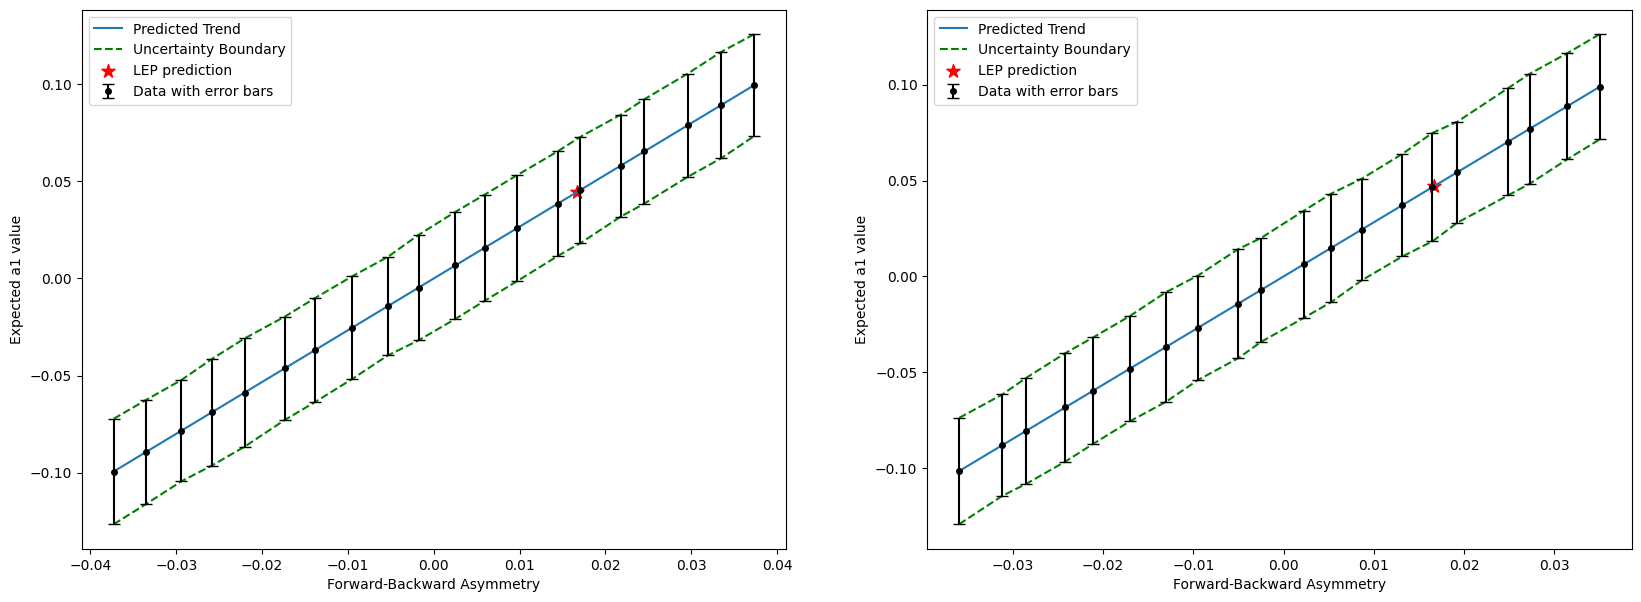

       Detector Type  Predicted a1 for LEP A_FB  Uncertainty
0          Ideal LEP                     0.0445       0.0035
1    Ideal Asymmetry                     0.0445       0.0273
2        Smeared LEP                     0.0471       0.0037
3  Smeared Asymmetry                     0.0471       0.0281
The ground-truth a1 DOESN`T fall within the uncertainties of the ideal LEP case
The ground-truth a1 DOESN`T fall within the uncertainties of the smeared LEP case


In [31]:
# 1. LEP A_FB
LEP_A_FB = [0.0167, 0.0013] # value, error

# 2. find the estimate for a1 & error
LEP_a1 = 2*(1 + gt_a2 / 3)*LEP_A_FB[0]
LEP_a1_err = 2*(1 + gt_a2 / 3)*LEP_A_FB[1] # if x has error δx, then F = kx has error δF = |k|δx

LEP_a1_smeared = 2*(1/0.9 + (0.9)*(gt_a2/3))*LEP_A_FB[0]
LEP_a1_smeared_err = 2*(1/0.9 + (0.9)*(gt_a2/3))*LEP_A_FB[1]
# ==========
# PLOTTING 
# ==========
# 3. re-plot the two trends for the ideal and smeared case with uncertainty boundaries 
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize=(20, 7))

# 4. plotting the uncertainty boundaries and data trend for the IDEAL CASE
ax[0].plot(A_FB_info[:, 0], a1_info[:, 0], label="Predicted Trend")
ax[0].plot(A_FB_info[:, 0], a1_lowers, c='g', linestyle='--', label='Uncertainty Boundary')
ax[0].plot(A_FB_info[:, 0], a1_uppers, c='g', linestyle='--')

# 5. plotting the actual data with error bars
ax[0].errorbar(x=A_FB_info[:,0], y=a1_info[:,0], yerr=a1_info[:,1], color='black', ls='none', fmt='o', label='Data with error bars', capsize=4.0, markersize=4)

# 6. scattering the LEP data:
ax[0].scatter(LEP_A_FB[0], LEP_a1, marker='*', color='red', label='LEP prediction', s=100)

ax[0].set_xlabel('Forward-Backward Asymmetry')
ax[0].set_ylabel('Expected a1 value')
ax[0].legend()


# 7. plotting the uncertainty boundaries and data trend for the SMEARED CASE
ax[1].plot(A_FB_info2[:, 0], a1_info2[:, 0], label="Predicted Trend")
ax[1].plot(A_FB_info2[:, 0], a1_lowers2, c='g', linestyle='--', label='Uncertainty Boundary')
ax[1].plot(A_FB_info2[:, 0], a1_uppers2, c='g', linestyle='--')

# 8. plotting the actual data with error bars
ax[1].errorbar(x=A_FB_info2[:,0], y=a1_info2[:,0], yerr=a1_info2[:,1], color='black', ls='none', fmt='o', label='Data with error bars', capsize=4.0, markersize=4)

# 9. scattering the LEP data:
ax[1].scatter(LEP_A_FB[0], LEP_a1_smeared, marker='*', color='r', label='LEP prediction', s=100)

ax[1].set_xlabel('Forward-Backward Asymmetry')
ax[1].set_ylabel('Expected a1 value')
ax[1].legend()

plt.show()

# ==========

# 10. mean uncertainty of a1 in both cases 
# ... this is the mean uncertainty of the DATA POINTS (a1_info[:, 1]), NOT the trend line.
exp_a1_avg_std = np.mean(a1_info[:,1])
exp_a1_avg_std2 = np.mean(a1_info2[:, 1])

# 11. find the value of a1 from the trend line AND its estimated uncertainty
xp = A_FB_info[:, 0]
yp = a1_info[:, 0]
exp_a1_trend = np.interp(LEP_A_FB[0], xp, yp)

# 12. Calculate the uncertainty of the IDEAL trend line at the LEP A_FB point ...
# ... by interpolating the uncertainty boundaries and taking half the difference.
a1_lowers_interp = np.interp(LEP_A_FB[0], xp, a1_lowers)
a1_uppers_interp = np.interp(LEP_A_FB[0], xp, a1_uppers)
# 13. Using half the difference between the bounds as the trend uncertainty
exp_a1_trend_err = (a1_uppers_interp - a1_lowers_interp) / 2

# 14. repeat for smeared 
xp2 = A_FB_info2[:, 0] 
yp2 = a1_info2[:, 0] 
exp_a1_trend2 = np.interp(LEP_A_FB[0], xp2, yp2) 

# ... Calculate the uncertainty of the SMEARED trend line at the LEP A_FB point
a1_lowers2_interp = np.interp(LEP_A_FB[0], xp2, a1_lowers2)
a1_uppers2_interp = np.interp(LEP_A_FB[0], xp2, a1_uppers2)
exp_a1_trend_err2 = (a1_uppers2_interp - a1_lowers2_interp) / 2


# 15. print results 
dataFrame2 = pd.DataFrame({
    'Detector Type':['Ideal LEP','Ideal Asymmetry', 'Smeared LEP', 'Smeared Asymmetry'], 
    'Predicted a1 for LEP A_FB':[round(LEP_a1, 4), round(exp_a1_trend, 4), round(LEP_a1_smeared, 4) ,round(exp_a1_trend2, 4)], 
    'Uncertainty':[round(LEP_a1_err, 4), round(exp_a1_trend_err, 4), round(LEP_a1_smeared_err, 4) ,round(exp_a1_trend_err2, 4)]
})
print(20*'=')
print(dataFrame2) 
print(20*'=')

# 16. print a 'yes/no' for if the errors are satisfactory
if (LEP_a1 - LEP_a1_err) <= gt_a1 <= (LEP_a1 + LEP_a1_err): 
    print('The ground-truth a1 DOES fall within the uncertainties of the ideal LEP case')
else:
    print('The ground-truth a1 DOESN`T fall within the uncertainties of the ideal LEP case')

if (LEP_a1_smeared - LEP_a1_smeared_err) <= gt_a1 <= (LEP_a1_smeared + LEP_a1_smeared_err): 
    print('The ground-truth a1 DOES fall within the uncertainties of the smeared LEP case')
else:
    print('The ground-truth a1 DOESN`T fall within the uncertainties of the smeared LEP case')
print(20*'=')

# Section 4

## Approach 1: Gradient Descent

There exist methods in machine learning by which a curve can be approximated by using gradient descent. The premise is that we start with a function mimicking the target distribution we're looking for, with randomly intialised coefficients. Then, evaluate this function at chosen 'x' values, comparing the result to what those values should correspond to on the true target distribution; depending on how different the results are, change those coefficients accordingly.

My first approach will mimic gradient descent using a maximum likelihood loss function:

1. Using the differential function, find the associated 'y' value for each cos(θ) value
2. Assign them: [cos(θ), dσ/dcosθ] ---> [x, y]
3. Choose random (between -1 and 1) values ($B, C$) of guessed parameters according to the fit: $$\hat{y} = 1 + B x + C x^2 $$
4. For each x, find $\hat{y}$ (the prediction), and compute the `mean-squared error` loss: $$\text{Loss} = L(\hat{y}, y) = \frac{1}{2n}\sum_n \left( \hat{y}_n - y_n\right)^2$$
5. find the loss derivatives: $$ \frac{∂L}{∂B}|_{B = B_t} $$ $$ \frac{∂L}{∂C}|_{C=C_t}$$
6. update the parameters: $$ B_{t+1} = B_t - \eta \frac{∂L}{∂B}|_{B = B_t} $$ $$ C_{t+1} = C_t - \eta \frac{∂L}{∂C}|_{C = C_t} $$
7. repeat the process for given iterations

This question follows directly on from `Question 2` and uses the same information as what's produced from the random initalisation of the real ($a_1, a_2$), along with the histogram features.

In [33]:
# ==========
# This code segment performs basic gradient descent on a quadratic regression model. The data points being fit are ...
# ... the bin centres and their corresponding bar heights properly scaled. 
# ==========

# 0. the actual y-value is the PDF height multiplied by the integral estimate
yscaled = yhist*area_est 
# 1. assign [x, y] 
y = yscaled
x = xhist
# 3. thetas = [B, C] and we choose two random values 
thetas = [np.random.uniform(-1, 1, 2).tolist()]
# 4a. setting the iteration limits and learning rate
niter = 0
niter_lim = 1e4
learn_rate = 0.01
# 4b. storing important trackers
losses = []

# 5. perform the gradient descent 
while niter < niter_lim:
  # 6. get a prediction
  B, C = thetas[-1]
  y_hat = target_func(x, B, C)
    
  # 7. find the error with the true value
  error = np.subtract(y_hat, y)
  # 8. mean-squared error loss
  mse_loss = np.sum(np.square(error)) / (2*len(y))
  losses.append(mse_loss)
    
  # 9. gradients of Loss for A, B and C
  dB = np.dot(error, x) / len(y)
  dC = np.dot(error, np.square(x) ) / len(y)
    
  # 10. update B & C parameters 
  thetas.append([B - learn_rate*dB, C - learn_rate*dC])
  if niter % 1000 == 0: # print loss after 1000 iterations 
    print(f'Iteration: {niter}; MSE Loss: {mse_loss}')
  # 11. Repeat
  niter += 1
print(f'Iteration: {niter}; MSE Loss: {mse_loss}')

Iteration: 0; MSE Loss: 0.24458031606555047
Iteration: 1000; MSE Loss: 0.006146040303963372
Iteration: 2000; MSE Loss: 0.004286973905737167
Iteration: 3000; MSE Loss: 0.004255954577911673
Iteration: 4000; MSE Loss: 0.004255387572755449
Iteration: 5000; MSE Loss: 0.004255377139308685
Iteration: 6000; MSE Loss: 0.004255376947234924
Iteration: 7000; MSE Loss: 0.004255376943698842
Iteration: 8000; MSE Loss: 0.004255376943633744
Iteration: 9000; MSE Loss: 0.004255376943632544
Iteration: 10000; MSE Loss: 0.004255376943632523


Now the model's been trained, we can plot the target function using the estimated parameter values against the true function's position

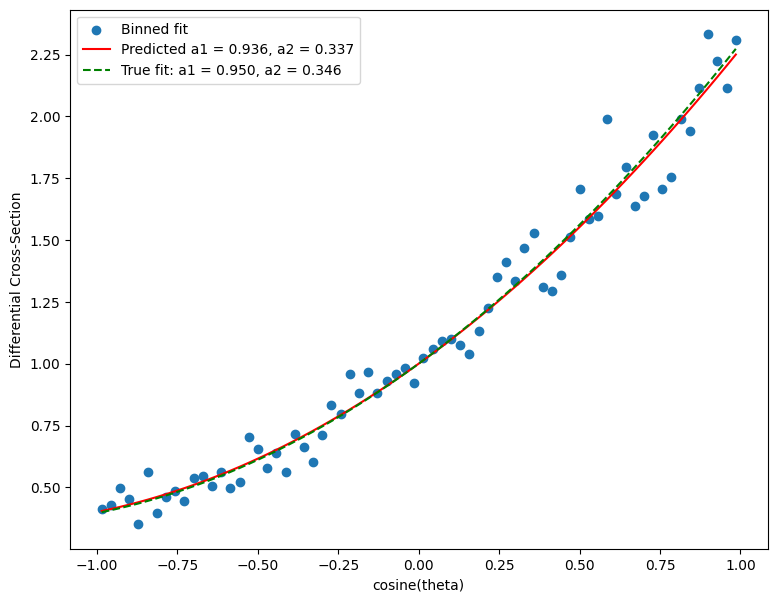

In [34]:
fig = plt.figure(figsize=(9, 7))
# 1. take the final value of the arguments for the target function
B = thetas[-1][0]
C = thetas[-1][1]
# 2. get an array of predicted function values
y_hat = target_func(xhist, B, C)
# 3. the true function values we expect
y_true = target_func(xhist, a1, a2)

# 4. scatter the true values 
plt.scatter(xhist, yscaled, label='Binned fit')
# 5. plot the predicted fit
plt.plot(xhist, y_hat, c ='r', label=f'Predicted a1 = {B:.3f}, a2 = {C:.3f}')
plt.plot(xhist, y_true, c='green',ls='--', label=f'True fit: a1 = {a1:.3f}, a2 = {a2:.3f}')
plt.xlabel('cosine(theta)')
plt.ylabel('Differential Cross-Section')
plt.legend()
plt.show()

Whilst a quadratic-regession model provides a good estimate to the parameters a1 and a2, it doesn't allow a thorough investigation of the variance, which is where we turn to the Chi-squared distribution:

## Approach 2: SciPy CurveFit

SciPy's `CurveFit` employs a 'goodness-of-fit' method, where the predicted values of (a1, a2) are chosen such that they maximise resemblance to the true data. Specifically, CurveFit uses a non-linear least-squares approach.

#### Note:

`popt` is array-like and contains the optimal values for the parameters such that the sum of the squared residuals is minimised.

`pcov` is a 2-D array providing an estimate to the covariance of popt, with diagonals providing the variance of the parameters to estimate. To find the std, labelled `perr`, we take the square-root of the diagonal.

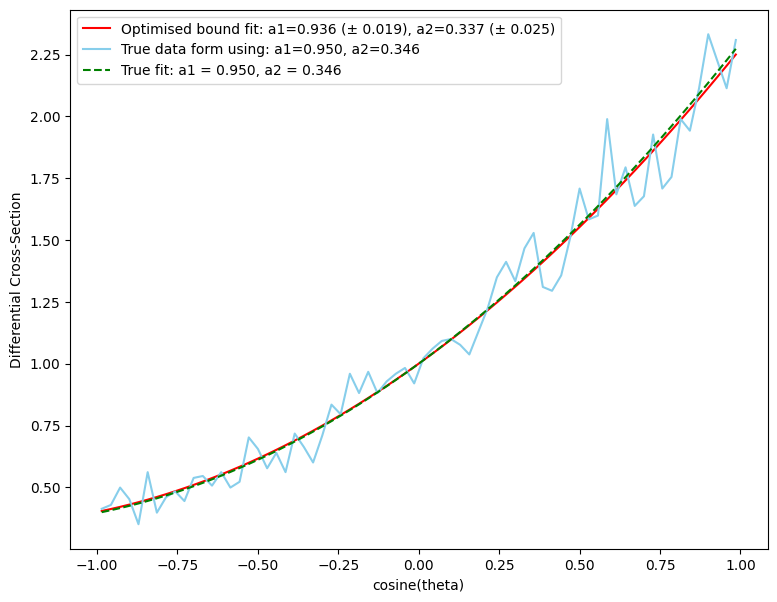

Unbound a1, a2 fit: standard deviation of a1, a2 is 0.019, 0.025
 Bound a1, a2 fit: standard deviation of a1, a2 is 0.019, 0.025

Therefore, the limits of a1 are [0.917, 0.956], and for a2 [0.312, 0.362]
SciPy is sufficiently accurate, as the predicted (a1, a2) lie within its uncertainty


In [35]:
fig = plt.figure(figsize=(9, 7))

# 1. the array of values to evaluate the function at
xdata = xhist
# 2. the array of corresponding histogram bar heights, rescaled to match that of the target functions height
ydata = yhist*area_est # the actual y-value is the PDF height multiplied by the integral estimate

# 3. Option to use Curvfit without bounds on the values of (a1, a2) estimates 
popt, pcov = curve_fit(target_func, xdata, ydata)
perr_unbound = np.sqrt(np.diag(pcov))
# plt.plot(xdata, target_func(xdata, *popt), 'r-', label='unbound fit: a1=%5.3f, a2=%5.3f' % tuple(popt))

# 4. constraining to the limits of the problem: this requires knowing the range that ...
# ... a1 and a2 can take 
popt, pcov = curve_fit(target_func, xdata, ydata, bounds=(-1., [1., 1.]))
perr_bound = np.sqrt(np.diag(pcov))

# 5. plotting the SciPy curvefit approach
plt.plot(xdata, target_func(xdata, *popt), 'r-',
         label='Optimised bound fit: a1={:.3f} (± {:.3f}), a2={:.3f} (± {:.3f})'.format(popt[0], perr_bound[0], popt[1], perr_bound[1]))

# 6. plotting the histogram bar heights
plt.plot(xdata, ydata,linestyle='-', label='True data form using: a1={:.3f}, a2={:.3f}'.format(a1, a2), c='skyblue')
# 7. plotting the fit using true (a1, a2)
plt.plot(xhist, y_true, c='green',ls='--', label=f'True fit: a1 = {a1:.3f}, a2 = {a2:.3f}')
# 8. figure
plt.xlabel('cosine(theta)')
plt.ylabel('Differential Cross-Section')
plt.legend()
plt.show()

# 9. quantifiying the upper and lower bound of estimated uncertainties 
a1_lower = popt[0] - perr_bound[0]
a1_upper = popt[0] + perr_bound[0]
a2_lower = popt[1] - perr_bound[1]
a2_upper = popt[1] + perr_bound[1] 

# 10. printing the results 
print(20*'=')
print('Unbound a1, a2 fit: standard deviation of a1, a2 is {:.3f}, {:.3f}\n'.format(perr_unbound[0], perr_unbound[1]),
    'Bound a1, a2 fit: standard deviation of a1, a2 is {:.3f}, {:.3f}\n'.format(perr_bound[0], perr_bound[1]))
print('Therefore, the limits of a1 are [{:.3f}, {:.3f}], and for a2 [{:.3f}, {:.3f}]'.format(a1_lower, a1_upper, a2_lower, a2_upper))
# 11. describing whether the true fit is contained within the uncertainties 
if a1_lower <= a1 <= a1_upper and a2_lower <= a2 <= a2_upper:
    print('SciPy is sufficiently accurate, as the predicted (a1, a2) lie within its uncertainty')
else:
    print('SciPy is not sufficiently accurate, as the predicted (a1, a2) do not lie within its uncertainty')
print(20*'=')

## Approach 3: Manually Minimising Chi-Squared

Continuing this approach of maximising the goodness-of-fit, we look now at the chi-squared value. The chi-square distribution tells us how good a function fits the true result we expect by comparing the squared-residuals between expectation and what's observed/predicted. The method is based on finding the conditions to minimise this quantity, meaning we look for the arguments of the function such that it most closely mimics the true data.

There are two forms of the chi-squared distribution (although we'll only consider the first):
1. From binned data following:
$$ \chi^2 = \sum_i^{\text{Bins}}\frac{(O_i - E_i)^2}{E_i} $$
where:
- $\chi ^2$ is the chi-squared statistic and is a number
- $O_i$ is the observed bin frequency for bin `i`
- $E_i$ is the expected bin frequency for bin `i`

This method compares the model's prediction with the bin population to the actual bin population and describes the goodness-of-fit of the model to the data. The OBSERVED bin population is **fixed** and determined by the inital values of a1 and a2, whereas the expected values are **varied** with varying a1 and a2 independently.


2. From Gaussian distributed data:
$$ \chi^2 = \sum_{i=1}^N \left( \frac{y_i - f(x_i~|~\vec{\theta})}{\sigma_i} \right)^2 $$
where:
- $y_i$ is the actual value of the function evaluated at position $x_i$
- $f(x_i|\vec{\theta})$ is the observed value of the function evaluated at $x_i$
- $\sigma_i$ is the standard deviation of $y_i$. How do I find the standard deviation of y?

This follows from the line of reasoning that we have precisely known x values with a corresponding y value and its associated uncertainty $\sigma$. The function, f, predicts the value of y for a given x and includes a number of parameters $\theta$.

**However**, due to the nature of this setting, we do not have an associated uncertainty for each measurement $y_i$, and so this method is unsuitable.

### Chi-squared from binned-fit

In this first method, each x value will will be the centre of each bin in the histogram plot. To find the *expected* bin frequency:
$$E_j = \frac{y_j \times \text{Bin width} \times \text{Total counts}}{\text{Integral area}}$$
where $y_j$ is the function value evaluated at some $x_j$ bin-centre.

To get the value of the function evaluated at each x we use the chosen true values of (a1, a2). The bin width and number of points contained is a constant and initalised with the histogram fit.

The *observed* bin frequency is found to be:
$$O_i = \text{i-th bar height} \times \text{Total counts} \times \text{Bin width}$$

where `i_th_bar_height` is the height of each histogram bar after being normalised.

Then, using the expected and observed counts, a chi-squared value can be generated for the predicted values of (a1, a2), which are contained within the observed bin frequency.

From this, we can create a meshgrid of a1 and a2 values and pass each combination to get a contour plot of how chi-squared varies with both parameters, which will enable us to find the minimum value.

### Subtask 1: Defining chi-squared functions
First, we define the two functions: one to return the chi-squared value for a particular configuration of predicted (a1, a2), the second to create a 3D landscape of how chi-squared varies with different configurations, allowing us to find the minimum value and best 'goodness-of-fit'

In [36]:
def chi_squared(xhist, bin_widths, obs, target_func, a1, a2, accept, N):
    """
    This function calculates the chi-squared value for a single binned fit distribution for a given value of a1 and a2

    Parameters
    ----------
    xhist: array
        the coordinates of the bin centres in the histogram
    bin_widths: float
        the width of each bin
    obs: array, shape=(Number of bins)
        the OBSERVED bin counts, which remains fixed for all trial predictions (a1, a2)
    target_func: callable
        the function to fit a binned distribution to
    a1: array, shape=(1, D)
        an array of trial values for the first coefficient in target_func
    a2: array , shape=(1, K)
        an array of trial values forthe second coefficient in target_func
    accept: float
        angular acceptance region. This determines the range of bins
    N: int
        the number of data points plotting in the histogram

    Returns
    ----------
    chi_sq: float
        the chi-squared statistic for this distribution
    ==========
    """

    # 1. Calculate expected bin counts using trial parameters (a1, a2). THIS IS THE VARIABLE
    y_exp = target_func(xhist, a1, a2)
    integral_area = sp.integrate.quad(target_func, -accept, accept, args=(a1, a2))[0]
    exp = (y_exp * bin_widths * N) / integral_area

    # now find chi-squared for the configuration
    scores = []
    # 2. for each bin/bar ...
    for i in range(len(exp)):
        # 3. only consider bins with expected counts > 0 to avoid division by zero
        if exp[i] > 0:
            # 4. difference
            diff = obs[i] - exp[i]
            # 5. squared-diff / expected 
            scores.append((diff**2 / exp[i]))

    # 6. summing all scores
    chi_sq = sum(scores)
    return chi_sq

In [37]:
def chi_square_landscape(
    target_func,
    chi_squared,
    obs,
    xhist,
    bin_widths,
    N,
    a1,
    a1_real,
    a2,
    a2_real,
    accept,
    plots):
    """
    This function is used to produce a minimum chi-squared value across a meshgrid of (a1, a2) values, plotting the landscape
    and returning an uncertainty.

    The function extracts necessary information from the description function and uses the array of (a1, a2) values to cycle through each
    configuration, generating a chi-squared value.

    The goodness-of-fit is determined by how close of a fit the permuted value of (a1,a2) is to the true value we're looking for. The true
    value is (a1_real, a2_real)

    Then, the minimum chi-squared can be found, along with the uncertainty on parameters a1 and a2, in a 2D landscape.

    Parameters
    ----------
    target_func: function
        the target function we're trying to evaluate
    chi_squared: function
        the function to calculate one chi-squared value for a single distribution
    obs: array, shape=(Number of bins)
        the OBSERVED bin counts, which remains fixed for all trial predictions (a1, a2)
    xhist: array
        the coordinates of the bin centres in the histogram
    bin_widths: float
        the width of each bin
    N: int
        the number of accepted points in the rejection sampling
    a1: float
        trial for first coefficient in target_func
    a1_real: float
        the true value of a1 we're approximating
    a2: float
        trial for first coefficient in target_func
    a2_real: float
        the true value of a2 we're approximating
    accept: float
        cosine of the angular acceptance
    plots: bool
        can plot the contour plot of a1, a2, chi-squared

    Returns
    ----------
    chi_squares: array, shape=(K, D)
        an array to store the chi-squared values for each configuration of a1 and a2
    a1_min: float
        the estimated value of a1
    a2_min: float
        the estimated value of a2
    err_a1: array, shape=(2, 1)
        the lower and upper error of parameter a1
    err_a2: array, shape=(2, 1)
        the lower and upper error of parameter a2

    If plots==True, the function will plot the 2D landscape with the chi-squared overlayed as a contour plot

    ==========
    """
    # 1. create a meshgrid of a1 and a2 values
    x, y = np.meshgrid(a1, a2)
    # 2. store the width/height of the landscape 
    width = x.shape[0]
    height = x.shape[1]

    # 3. for each (x, y) calculate the chi-squared statistic. ...
    # ... rather than using a double loop, vectorising the problem makes it quicker
    chi_squares = np.array([[chi_squared(xhist, bin_widths, obs, target_func,
                                      x[h, w], y[h, w], accept, N) for w in range(width)] for h in range(height)])

    # 4. now we can find the minimum value of chi-squared and its associated a1, a2
    index = np.where(chi_squares == min(chi_squares.flatten()))
    a1_min = x[index][0]
    a2_min = y[index][0]

    # 5. define fig 
    fig = plt.figure(figsize=(12, 7))

    # 6. contour line for minimum χ+1 to find the uncertainties on (a1, a2)
    contour_line = plt.contour(x, y, chi_squares, levels=[min(chi_squares.flatten())+2], colors='orange', linewidths=2) # chi_min + 1 ring
    # 7. close figure if not plotting
    if plots==False:
        plt.close()
        
    # 8. Extract coordinates using get_paths()
    path = contour_line.get_paths()[0]
    # ... This is the array of x,y coordinates, with shape (Number of χ+1 points, 2)
    coordinates = path.vertices
    
    # 9. the uncertainty on a1 estimates.
    err_a1 = np.array([abs(a1_min - min(coordinates[:,0])), abs(a1_min - max(coordinates[:,0]))]) # [lower error, upper error]
    err_a1 = np.reshape(err_a1, (2, 1)) # I've reshaped it to fit into the error bar plotting
    a1_lower, a1_upper = err_a1[0][0], err_a1[1][0]
    
    # 10. the uncertainty on a2 estimates.
    err_a2 = np.array([abs(a2_min - min(coordinates[:,1])), abs(a2_min - max(coordinates[:,1]))]) # [lower error, upper error]
    err_a2 = np.reshape(err_a2, (2, 1))
    a2_lower, a2_upper = err_a2[0][0], err_a2[1][0]

    # 11. plotting the landscape 
    if plots == True:
        # 12. contour the meshgrid with chi-squared values
        contour_plot = plt.contourf(x, y, chi_squares, cmap='viridis') 
        # 13. contour line of minimum χ+1
        contour_line_plot = plt.contour(x, y, chi_squares, levels=[min(chi_squares.flatten())+2], colors='red', linewidths=2.5) # chi_min + 1 ring
        plt.clabel(contour_line_plot, inline=True, inline_spacing = 10, fontsize=12, fmt='χ+2')

        
        # 14. plot the min value of χ
        plt.scatter(a1_min, a2_min, c='red', s=120, edgecolors='white', linewidth=2, label='Minimum value of chi-squared: a1={:.2f}(+{:.2f}, -{:.2f}), a2={:.2f}(+{:.2f}, -{:.2f})'.format(
            a1_min, a1_lower, a1_upper, a2_min, a2_lower, a2_upper)) # coords of minimum with uncertainties
        # 15. plot the error bars
        plt.errorbar(a1_min, a2_min, yerr=err_a2, xerr=err_a1, ecolor='black', elinewidth=2, capsize=6)

        # 16. scatter the true values of (a1, a2)
        plt.scatter(a1_real, a2_real, c='lime', label='True values, a1={:.2f}, a2={:.2f}'.format(a1_real, a2_real), marker='*', s=200, edgecolors='black')
        # 17. figure / axis information
        plt.xlabel('a1', fontsize=14, fontweight='bold')
        plt.ylabel('a2', fontsize=14, fontweight='bold')
        plt.grid(alpha=0.4)
        plt.clim(min(chi_squares.flatten()), max(chi_squares.flatten()))
        plt.colorbar()
        plt.legend(fontsize=11)
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)

        plt.savefig('fig3.png', dpi=300, bbox_inches='tight')
        plt.show()


    return chi_squares, a1_min, a2_min, err_a1, err_a2

### Subtask 2: Contour plot of chi-squared
Fix the true values of (a1, a2) and visualise how chi-squared varies with trial (a1, a2) values

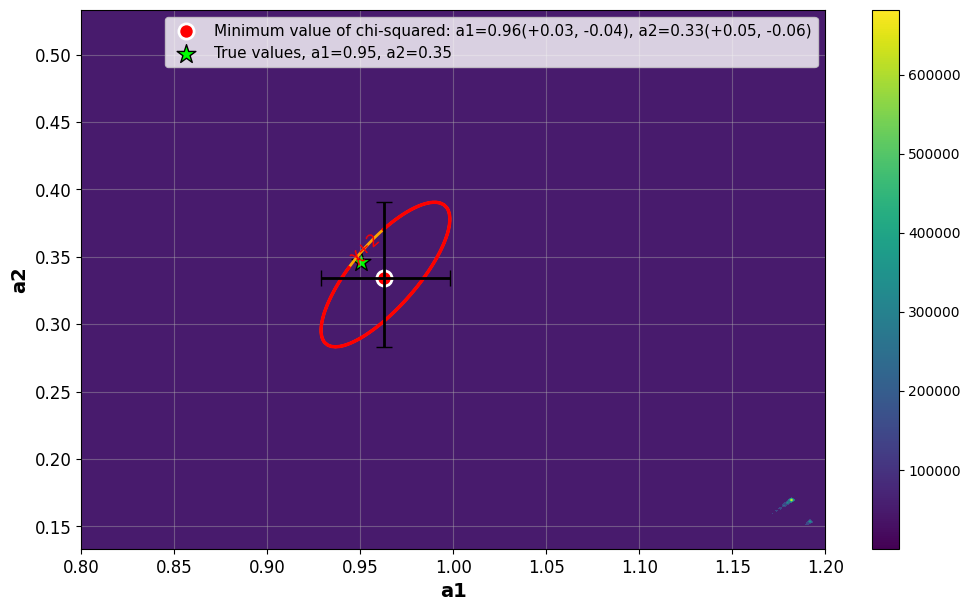

Chi-squared approach is sufficiently accurate, as the predicted (a1, a2) lie within its uncertainty


In [40]:
# 1. defining contstants/parameters
N = 1e4
a1_real = a1
a2_real = a2

# 2. Getting the observed bin counts for the true (a1, a2)
xhist, yhist, bin_widths, p_max, area_est, total_vals, accepted_vals = distribution_descrip(
        target_func, sample_gen, N, a1_real, a2_real, accept, chi_sq=True) # set chi_sq = True
# ... recall yhist is the histogram bar heights to find the OBSERVED bin count. THIS IS FIXED
obs = yhist * N * bin_widths


# 3. Define search grids for (a1, a2)
A1 = np.linspace(-1, 1, 10)
A2 = np.linspace(-1, 1, 10)

# 4. First search using wide area region. This should land us within the vicinity ... 
# ... of the true (a1, a2)
chi_squares, a1_est, a2_est, err_a1, err_a2 = chi_square_landscape(
    target_func,      
    chi_squared,
    obs,
    xhist,
    bin_widths,
    N,
    A1,
    a1_real,
    A2,
    a2_real,
    accept,
    plots=False
)


# 5. Finer search around the predicted (a1, a2) from the broad search 
A1_fine = np.linspace(a1_est - 0.2, a1_est + 0.2, 200)
A2_fine = np.linspace(a2_est - 0.2, a2_est + 0.2, 200)
# "CS" is just used to separate these values from later ones so they can be used in a table 
chi_squares, CS_a1_est, CS_a2_est, CS_err_a1, CS_err_a2 = chi_square_landscape(
    target_func,      
    chi_squared,
    obs,
    xhist,
    bin_widths,
    N,
    A1_fine,
    a1_real,
    A2_fine,
    a2_real,
    accept,
    plots=True
)

# 6. quantify the lower & upper uncertainty bounds for the predicted (a1, a2)
a1_lower = CS_a1_est - CS_err_a1[0, 0]
a1_upper = CS_a1_est + CS_err_a1[1, 0]
a2_lower = CS_a2_est - CS_err_a2[0, 0]
a2_upper = CS_a2_est + CS_err_a2[1, 0]

# 7. print results 
print(20*'=')
if a1_lower <= a1_real <= a1_upper and a2_lower <= a2_real <= a2_upper:
    print('Chi-squared approach is sufficiently accurate, as the predicted (a1, a2) lie within its uncertainty')
else:
    print('Chi-squared approach is not sufficiently accurate, as the predicted (a1, a2) do not lie within its uncertainty')
print(20*'=')

There's an unpredictability of the search - sometimes the chi-squared gets it right, sometimes not. To test how often it can identify the correct (a1, a2) values we simulate 100 trials. 

The following code will take a moment to run, so a progress bar has been included.

In [41]:
# 1. counters
n_trials = 100
coverage_count = 0

# 2. reproduce the chi-squared distribution 100 times 
for trial in tqdm(range(n_trials)):
    # 3. generate new observed data
    xhist, yhist, bin_widths, p_max, area_est, total_vals, accepted_vals = distribution_descrip(
        target_func, sample_gen, N, a1_real, a2_real, accept, chi_sq=True)
    # 4. observed bin count 
    obs = yhist * N * bin_widths
    
    # 5. run chi-squared fit using finer-regoin for (a1, a2) meshgrid 
    chi_squares, a1_est, a2_est, err_a1, err_a2 = chi_square_landscape(
        target_func, chi_squared, obs, xhist, bin_widths, N,
        A1_fine, a1_real, A2_fine, a2_real, accept, plots=False)
    
    # 6. Check if true values are within errors
    a1_lower = a1_est - err_a1[0, 0]
    a1_upper = a1_est + err_a1[1, 0]
    a2_lower = a2_est - err_a2[0, 0]
    a2_upper = a2_est + err_a2[1, 0]
    
    if (a1_lower <= a1_real <= a1_upper) and (a2_lower <= a2_real <= a2_upper):
        coverage_count += 1

# 7. print the % correct
coverage = coverage_count / n_trials
print(f"Coverage: {coverage*100:.1f}%")
print(f"Expected: ~68.0% for 1σ errors on 2D parameters")

100%|██████████| 100/100 [02:17<00:00,  1.37s/it]

Coverage: 80.0%
Expected: ~68.0% for 1σ errors on 2D parameters


For 1D parameter search, we expect the true value to fall within `χ+1` roughly ~68% of the time, since this indicates ± 1σ deviation. 

For 2D parameters, we expect the true values to fall within `χ+1` roughly ~39% of the time, since this indicates ± 1σ deviation in 2-dimensions.

According to a paper on this topic though, if we change `χ+1` to `χ+2` then for 2D parameter search we expect ~68% again, so this adjustment was made to the code.

### Interpretation:
`Coverage << 68%`: this tells us that the chi-squared method is underperforming and is likely encountering either systematic errors in code implementation or there's a fundamental flaw in the sampling process whereby the source of randomness is being manipulated.

`Coverage ≈ 68%`: the chi-squared method is performing accurately

`Coverage >> 68%`: whilst this may seem like a good result, the overachievement of the method is likely down to the error boxes surrounding the estimated (a1, a2) not being elliptical like the distribution itself. A more scrutinous method should be implemented to only consider success if the true values lie within the elliptical region of `χ+2` 


### Subtask 3: Uncertainty variation with different value of N

As a way of comparing the method of chi-squared to the forward-backward asymmetry of Question 2, now investigate the variation of the uncertainty on `(a_1, a_2)` with `N`.

In [42]:
# 1. range of N values 
N_range = np.logspace(start=1, stop=4, num=16)
# 2. true values 
a1_real = a1
a2_real = a2

# 3. empty arrays to store
avg_a1_errors = np.empty(shape=(len(N_range), 1))
avg_a2_errors = np.empty(shape=(len(N_range), 1))

# 4. cycle through N values
for n, N in enumerate(N_range): 
    # 5. observed bin count
    xhist, yhist, bin_widths, p_max, area_est, total_vals, accepted_vals = distribution_descrip(
        target_func, sample_gen, N, a1_real, a2_real, accept, chi_sq=True) # set chi_sq = True
    # ... recall yhist is the histogram bar heights to find the OBSERVED bin count. THIS IS FIXED
    obs = yhist * N * bin_widths
    
    # 6. Define search grids
    A1 = np.linspace(-1, 1, 10)
    A2 = np.linspace(-1, 1, 10)
    
    # 7. First, broad search
    chi_squares, a1_est, a2_est, err_a1, err_a2 = chi_square_landscape(
        target_func,      
        chi_squared,
        obs,
        xhist,
        bin_widths,
        N,
        A1,
        a1_real,
        A2,
        a2_real,
        accept,
        plots=False
    )
    
    # 8. Second, finer search around the minimum
    A1_fine = np.linspace(a1_est - 0.3, a1_est + 0.3, 100)
    A2_fine = np.linspace(a2_est - 0.3, a2_est + 0.3, 100)
    
    chi_squares, a1_est, a2_est, err_a1, err_a2 = chi_square_landscape(
        target_func,      
        chi_squared,
        obs,
        xhist,
        bin_widths,
        N,
        A1_fine,
        a1_real,
        A2_fine,
        a2_real,
        accept,
        plots=False
    )
    # 9. finding the mean error. Both values in "err_a" are positive therefore this is absolute error either side
    a1_avg_err = np.mean(err_a1)
    a2_avg_err = np.mean(err_a2)

    avg_a1_errors[n] = a1_avg_err
    avg_a2_errors[n] = a2_avg_err


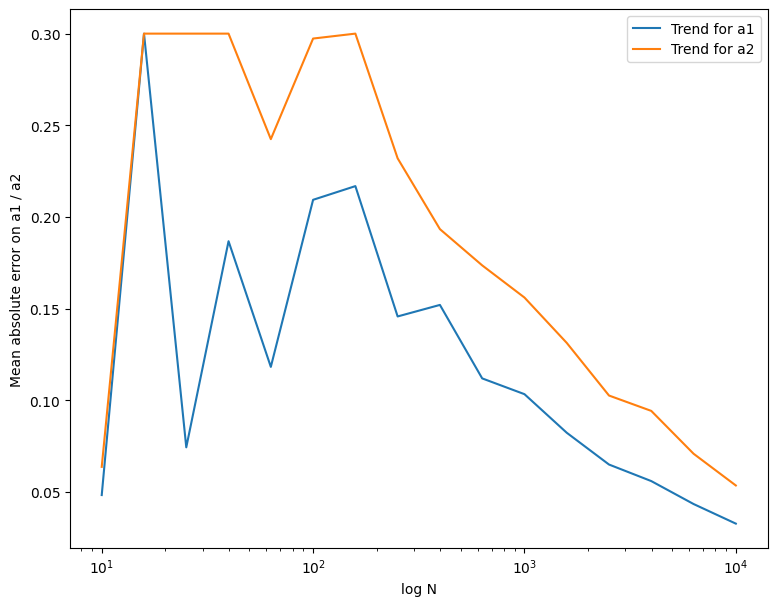

In [43]:
fig = plt.figure(figsize=(9, 7))
plt.plot(N_range, avg_a1_errors, label='Trend for a1')
plt.plot(N_range, avg_a2_errors, label='Trend for a2')
plt.ylabel('Mean absolute error on a1 / a2')
plt.xlabel('log N')
plt.xscale('log') 
plt.legend()
plt.show()

What can be tested now is how the choice of true `(a_1, a_2)` affects the shape.

To do this, **only consider the mean absolute uncertainty on a1** (allows for comparison with Questions 2 and 3) and create two plots, in which the first plot fixes true a2 and the second fixes true a1, varying the other in both cases.

#### The following code takes a while to run, a progress indicator has been added.

Plot 1, iteration: 1/5
Plot 1, iteration: 2/5
Plot 1, iteration: 3/5
Plot 1, iteration: 4/5
Plot 1, iteration: 5/5
Plot 2, iteration: 1/5
Plot 2, iteration: 2/5
Plot 2, iteration: 3/5
Plot 2, iteration: 4/5
Plot 2, iteration: 5/5


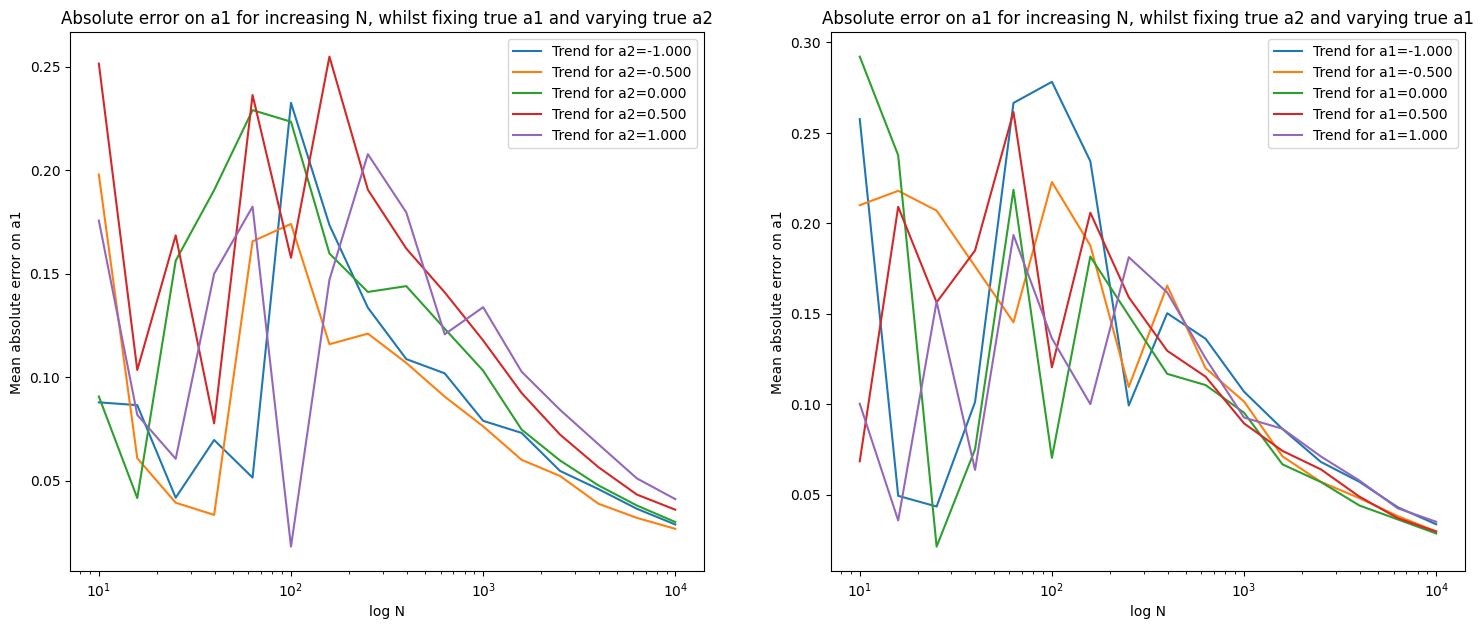

In [44]:
# 0. use A1 and A2 linspaces from before 

# 1. create figure
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# 2. ranges for a1 and a2
A1s = np.linspace(-1, 1, 5)
A2s = np.linspace(-1, 1, 5)

# 3. keeping a1 fixed and cycling through a2 values 
for k, a2_test in enumerate(A2s): # a2_test replaces a2_real i.e becomes the true value in the called functions
    # 4. keep a1 fixed
    a1_real = a1
    # 5. create array to store plotting information each time. Remember we are ONLY interested in a1's error variation
    varied_mean_abs_a1_err = np.empty(shape=(len(N_range), 1))

    # 6. cycle through N values for this instance of (a1_test, a2)
    for n, N in enumerate(N_range): 
        xhist, yhist, bin_widths, p_max, area_est, total_vals, accepted_vals = distribution_descrip(
            target_func, sample_gen, N, a1_real, a2_test, accept, chi_sq=True) # set chi_sq = True
        # ... recall yhist is the histogram bar heights to find the OBSERVED bin count. THIS IS FIXED
        obs = yhist * N * bin_widths
        
        # 7. Define search grids
        A1 = np.linspace(-1, 1, 10)
        A2 = np.linspace(-1, 1, 10)
        
        # 8. First, broad search
        chi_squares, a1_est, a2_est, err_a1, err_a2 = chi_square_landscape(
            target_func,      
            chi_squared,
            obs,
            xhist,
            bin_widths,
            N,
            A1,
            a1_real,
            A2,
            a2_test,
            accept,
            plots=False
        )
        
        # 9. Second, fine search around the minimum
        A1_fine = np.linspace(a1_est - 0.3, a1_est + 0.3, 100)
        A2_fine = np.linspace(a2_est - 0.3, a2_est + 0.3, 100)
        
        chi_squares, a1_est, a2_est, err_a1, err_a2 = chi_square_landscape(
            target_func,      
            chi_squared,
            obs,
            xhist,
            bin_widths,
            N,
            A1_fine,
            a1_real,
            A2_fine,
            a2_test,
            accept,
            plots=False
        )
        # 10. finding the mean error. Both values in "err_a" are positive therefore this is absolute error either side
        a1_avg_err = np.mean(err_a1)
        varied_mean_abs_a1_err[n] = a1_avg_err

    # 11. plotting the trend for each combination
    ax[0].plot(N_range, varied_mean_abs_a1_err, label=f'Trend for a2={a2_test:.3f}')
    print(f'Plot 1, iteration: {(k+1)}/{len(A2s)}')

# 12.  keeping a2 fixed and cycling through a1 values 
for k, a1_test in enumerate(A1s): # a1_test replaces a1_real i.e becomes the true value in the called functions
    # keep a2 fixed
    a2_real = a2 
    # 13. create array to store plotting information each time. Remember we are ONLY interested in a1's error variation
    varied_mean_abs_a1_err = np.empty(shape=(len(N_range), 1))

    # 14. cycle through N values for this instance of (a1_test, a2)
    for n, N in enumerate(N_range): 
        xhist, yhist, bin_widths, p_max, area_est, total_vals, accepted_vals = distribution_descrip(
            target_func, sample_gen, N, a1_test, a2_real, accept, chi_sq=True) # set chi_sq = True
        # ... recall yhist is the histogram bar heights to find the OBSERVED bin count. THIS IS FIXED
        obs = yhist * N * bin_widths
        
        # 15. Define search grids
        A1 = np.linspace(-1, 1, 10)
        A2 = np.linspace(-1, 1, 10)
        
        # 16. First, broad search
        chi_squares, a1_est, a2_est, err_a1, err_a2 = chi_square_landscape(
            target_func,      
            chi_squared,
            obs,
            xhist,
            bin_widths,
            N,
            A1,
            a1_test,
            A2,
            a2_real,
            accept,
            plots=False
        )
        
        # 17. Second, fine search around the minimum
        A1_fine = np.linspace(a1_est - 0.3, a1_est + 0.3, 100)
        A2_fine = np.linspace(a2_est - 0.3, a2_est + 0.3, 100)
        
        chi_squares, a1_est, a2_est, err_a1, err_a2 = chi_square_landscape(
            target_func,      
            chi_squared,
            obs,
            xhist,
            bin_widths,
            N,
            A1_fine,
            a1_test,
            A2_fine,
            a2_real,
            accept,
            plots=False
        )
        # 18. finding the mean error. Both values in "err_a" are positive therefore this is absolute error either side
        a1_avg_err = np.mean(err_a1)
        varied_mean_abs_a1_err[n] = a1_avg_err

    ax[1].plot(N_range, varied_mean_abs_a1_err, label=f'Trend for a1={a1_test:.3f}')
    print(f'Plot 2, iteration: {(k+1)}/{len(A1s)}')


ax[0].set_ylabel('Mean absolute error on a1')
ax[0].set_xlabel('log N')
ax[0].set_xscale('log') 
ax[0].set_title('Absolute error on a1 for increasing N, whilst fixing true a1 and varying true a2')
ax[0].legend()

ax[1].set_ylabel('Mean absolute error on a1')
ax[1].set_xlabel('log N')
ax[1].set_xscale('log') 
ax[1].set_title('Absolute error on a1 for increasing N, whilst fixing true a2 and varying true a1')
ax[1].legend()
plt.savefig('fig4.png')
plt.show()


Whilst both plots appear to be irratic when `N < 1000`, there is a noticable trend afterwards as the mean absolute error in all cases begins to decline uniformly. This provides better understanding as to what the threshold should be to obtain 'meaningful' results from the rejection sampling technique when applied to chi-squared as a means of testing goodness of fit.

The likely cause of this behaviour is from the Monte Carlo random sampling, and the information we require being sensitive to the statistical fluctuations in results generated for 'small' values of `N`.

In [45]:
# 1. in the dataframe we have to carefully choose which statistics to include (all with N=10000)

# 2. for the F-B we use the `estimates()` function since this provides the mean and an uncertainty, whereas 
# ... the standard F-B only provides an estimate. 
FB_a1_est = round(pred_a1_mean, 4)
FB_a1_err = round(pred_a1_std, 4)

# 3. for the smeared F-B case we do the same 
SFB_a1_est = round(pred_a1_mean2, 4)
SFB_a1_err = round(pred_a1_std2, 4)

# 4. for Quad-Reg, we only get a single value and the model is deterministic so ... 
# ... we would get an error of zero 
QR_a1_est = round(B , 4)
QR_a2_est = round(C, 4)

# 5. for CurveFit, it comes with estimate and uncertainty 
CF_a1_est, CF_a1_err, CF_a2_est, CF_a2_err = round(popt[0], 4), round(perr_bound[0], 4), round(popt[1], 4), round(perr_bound[1], 4)

#6. for chi-squared, we perform the broad search -> fine search and return the estimate and uncertainties
CS_a1_est = round(CS_a1_est, 4)
CS_a1_err = [round(-CS_err_a1[0, 0], 4), round(CS_err_a1[1, 0], 4)]
CS_a2_est = round(CS_a2_est, 4)
CS_a2_err = [round(-CS_err_a2[0, 0], 4), round(CS_err_a2[1, 0], 4)]

# 7. actual difference
a1_diff = np.round(a1 - [FB_a1_est, SFB_a1_est, QR_a1_est, CF_a1_est, CS_a1_est], 4)

a2_diff = np.round(a2 - [np.nan, np.nan, QR_a2_est, CF_a2_est, CS_a2_est], 4)

df = pd.DataFrame({
    'Method': ['Ideal F-B', 'Smeared F-B', 'Quad-Reg', 'CurveFit', 'Chi-Squared'],
    'Estimated a1 (N=10000)' : [FB_a1_est, SFB_a1_est, QR_a1_est, CF_a1_est, CS_a1_est], 
    'Absolute a1 Uncertainty': [FB_a1_err, SFB_a1_err, np.nan, CF_a1_err, CS_a1_err],
    '(a1_true - a1_est)' : a1_diff,
    'Estimated a2 (N=10000)': [np.nan, np.nan, QR_a2_est, CF_a2_est, CS_a2_est], 
    'Absolute a2 Uncertainty': [np.nan, np.nan, np.nan, CF_a2_err, CS_a2_err], 
    '(a2_true - a2_est)': a2_diff
})

In [46]:
df 

,Method,Estimated a1 (N=10000),Absolute a1 Uncertainty,(a1_true - a1_est),Estimated a2 (N=10000),Absolute a2 Uncertainty,(a2_true - a2_est)
0,Ideal F-B,0.9503,0.0207,0.0001,NaN,NaN,NaN
1,Smeared F-B,0.9496,0.0223,0.0008,NaN,NaN,NaN
2,Quad-Reg,0.9363,NaN,0.0141,0.3367,NaN,0.0095
3,CurveFit,0.9363,0.0194,0.0141,0.3367,0.025,0.0095
4,Chi-Squared,0.9628,"[-0.0338, 0.0354]",-0.0124,0.3343,"[-0.0512, 0.0561]",0.0119
